# ROPAgen Document Evaluation
## ModernBERT-based NLP Metrics for 2,000-Token German GDPR Documents

**Metrics:** BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Cosine Similarity  
**Model:** `answerdotai/ModernBERT-base` — Alternating Global-Local Attention + RoPE, 8,192-token native window  
**Hardware target:** RTX 4070 (CUDA) with batch processing to prevent OOM

In [70]:
import os, warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()   # loads HF_TOKEN (and any other vars) from .env

import pandas as pd
import numpy as np
import torch
import evaluate
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

# ── Configuration ──────────────────────────────────────────────────────────────
MODEL_NAME       = "answerdotai/ModernBERT-base"
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
BERT_BATCH_SIZE  = 4   # conservative for RTX 4070 + 2k-token docs
SBERT_BATCH_SIZE = 4

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU    : {props.name}")
    print(f"VRAM   : {props.total_memory / 1e9:.1f} GB")
print(f"HF_TOKEN set: {bool(os.environ.get('HF_TOKEN'))}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4070
VRAM   : 12.9 GB
HF_TOKEN set: True


In [71]:
# ── Load reference document ────────────────────────────────────────────────────
with open("docs/reference.txt", "r", encoding="utf-8") as fh:
    reference_text = fh.read().strip()

print(f"Reference length : {len(reference_text):,} chars  |  "
      f"~{len(reference_text.split()):,} words")

# ── Load candidate documents ───────────────────────────────────────────────────
df_all = pd.read_csv("docs/documents.csv")
df_all = df_all.dropna(subset=["ai_mode"])   # drop rows with missing ai_mode
print(f"\nTotal candidates : {len(df_all)}")
print(f"Columns          : {df_all.columns.tolist()}")
print(f"\nMode distribution:")
print(df_all["ai_mode"].value_counts().to_string())

# ── Split by mode ──────────────────────────────────────────────────────────────
MODES = sorted(df_all["ai_mode"].unique().tolist())
dfs_by_mode = {
    mode: df_all[df_all["ai_mode"] == mode].reset_index(drop=True)
    for mode in MODES
}
print(f"\nMode keys: {MODES}")

Reference length : 3,532 chars  |  ~393 words

Total candidates : 113
Columns          : ['id', 'user_id', 'ai_mode', 'document']

Mode distribution:
ai_mode
chat    39
form    37
ask     37

Mode keys: ['ask', 'chat', 'form']


## Metric Definitions

| Metric | Purpose | Notes |
|---|---|---|
| **BLEU** | N-gram precision overlap | Modified precision; baseline surface similarity |
| **ROUGE-1/2** | Unigram / bigram recall | Measures lexical coverage |
| **ROUGE-L** | Longest common subsequence | Captures sentence-level structure |
| **METEOR** | Synonym-aware recall | Stems + synonyms → better semantic recall than BLEU |
| **BERTScore Recall** | Token-level contextual overlap | ModernBERT embeddings; focus on *recall* per supervisor |
| **SBERT Similarity** | Global document-level cosine sim | Pooled ModernBERT embeddings; holistic semantic match |

In [72]:
# ── Load evaluate metrics (done once; reused across modes) ─────────────────────
print("Loading evaluate metrics …")
bleu_metric    = evaluate.load("bleu")
rouge_metric   = evaluate.load("rouge")
meteor_metric  = evaluate.load("meteor")
print("Done.")

# ── Baseline: BLEU · ROUGE · METEOR ───────────────────────────────────────────
def compute_baseline_metrics(candidates: list[str], reference: str) -> pd.DataFrame:
    """
    Compute BLEU, ROUGE-1, ROUGE-2, ROUGE-L, and METEOR document-by-document.

    METEOR is highlighted because it matches stems and WordNet synonyms,
    giving more credit for paraphrased recall than BLEU's precision-only view.
    """
    rows = []
    for cand in tqdm(candidates, desc="  baseline", leave=False):
        row = {}

        # BLEU — modified n-gram precision (references wrapped in a list)
        try:
            b = bleu_metric.compute(predictions=[cand], references=[[reference]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = np.nan

        # ROUGE
        r = rouge_metric.compute(predictions=[cand], references=[reference])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        # METEOR — synonym-aware recall via stemming + WordNet alignment
        m = meteor_metric.compute(predictions=[cand], references=[reference])
        row["METEOR"] = m["meteor"]

        rows.append(row)

    return pd.DataFrame(rows)

Loading evaluate metrics …
Done.


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\emilija\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [73]:
import torch.nn.functional as F

# ── Load ModernBERT once for BERTScore (evaluate's bert_score library does not
#    support ModernBERT's architecture — we call AutoModel directly instead) ────
print(f"Loading tokenizer & model for BERTScore: {MODEL_NAME} …")
_bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
_bert_model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
_bert_model.eval()
print("Done.")


def _embed_texts(texts: list[str], batch_size: int) -> list[torch.Tensor]:
    """Return one L2-normalised (valid_tokens × hidden_dim) tensor per text."""
    embeddings: list[torch.Tensor] = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = _bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=8192,
            return_tensors="pt",
        ).to(DEVICE)
        with torch.no_grad():
            out = _bert_model(**enc)
        hidden = out.last_hidden_state        # (B, T, H)
        mask   = enc["attention_mask"].bool() # (B, T)
        for j in range(len(batch)):
            emb = hidden[j][mask[j]]          # strip padding → (T_valid, H)
            embeddings.append(F.normalize(emb, dim=-1))
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return embeddings


def compute_bertscore(
    candidates: list[str],
    reference: str,
    batch_size: int = BERT_BATCH_SIZE,
) -> tuple[list[float], list[float], list[float]]:
    """
    BERTScore Precision, Recall, and F1 using ModernBERT token embeddings.

    P_BERT  = mean over candidate tokens of max cosine sim to any reference token
    R_BERT  = mean over reference tokens  of max cosine sim to any candidate token
    F1_BERT = harmonic mean of P and R

    Because embeddings are L2-normalised, cosine sim = dot product.
    """
    [ref_emb] = _embed_texts([reference], batch_size=1)   # (T_ref, H)
    cand_embs  = _embed_texts(candidates, batch_size=batch_size)

    precisions, recalls, f1s = [], [], []
    for c_emb in tqdm(cand_embs, desc="  BERTScore", leave=False):
        sim = ref_emb @ c_emb.T                          # (T_ref, T_cand)
        r   = sim.max(dim=1).values.mean().item()        # recall:    max over cand per ref token
        p   = sim.max(dim=0).values.mean().item()        # precision: max over ref  per cand token
        f1  = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)

    return precisions, recalls, f1s

Loading tokenizer & model for BERTScore: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 13930.42it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done.


In [74]:
# ── SBERT Global Semantic Similarity (ModernBERT-base, CUDA, batched) ──────────
print(f"Loading SentenceTransformer: {MODEL_NAME} …")
sbert_model = SentenceTransformer(MODEL_NAME, device=DEVICE)

# Override the default 512-token limit; ModernBERT supports 8,192 natively
sbert_model.max_seq_length = 8192
print(f"Max seq length : {sbert_model.max_seq_length}")
print(f"Embedding dim  : {sbert_model.get_sentence_embedding_dimension()}")

# Pre-encode the reference once (reused for every mode)
ref_embedding = sbert_model.encode(
    [reference_text],
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2-normalise → dot product == cosine sim
    show_progress_bar=False,
)   # shape: (1, hidden_dim)

def compute_sbert_similarity(
    candidates: list[str],
    batch_size: int = SBERT_BATCH_SIZE,
) -> list[float]:
    """
    Encode each candidate with the shared ModernBERT SentenceTransformer and
    compute cosine similarity against the pre-encoded reference embedding.

    Because both vectors are L2-normalised, cosine similarity reduces to a
    simple dot product — no extra trig needed.
    """
    cand_embeddings = sbert_model.encode(
        candidates,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )   # shape: (n, hidden_dim)

    # dot product of unit vectors == cosine similarity
    sims = (cand_embeddings @ ref_embedding.T).squeeze()

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    # ensure we always return a plain Python list
    return sims.tolist() if hasattr(sims, "tolist") else [float(sims)]

Loading SentenceTransformer: answerdotai/ModernBERT-base …


Loading weights: 100%|██████████| 134/134 [00:00<00:00, 15337.34it/s]
ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 8192
Embedding dim  : 768


In [75]:
# ── Compute all metrics per mode ───────────────────────────────────────────────
METRIC_COLS = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
               "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
               "SBERT_ModernBERT"]

mode_results: dict[str, pd.DataFrame] = {}

for mode in MODES:
    df_mode    = dfs_by_mode[mode]
    candidates = df_mode["document"].astype(str).tolist()
    n          = len(candidates)

    print(f"\n{'═'*60}")
    print(f"  Mode: '{mode}'  ({n} documents)")
    print(f"{'═'*60}")

    # 1. Lexical / surface metrics
    df_base = compute_baseline_metrics(candidates, reference_text)

    # 2. BERTScore Precision, Recall, F1 — ModernBERT token-level
    precisions, recalls, f1s = compute_bertscore(candidates, reference_text)

    # 3. SBERT Cosine Similarity — global document-level semantic similarity
    sims = compute_sbert_similarity(candidates)

    # Assemble per-mode DataFrame
    df_result = df_mode[["id", "user_id", "ai_mode"]].copy()
    df_result = pd.concat(
        [df_result.reset_index(drop=True),
         df_base.reset_index(drop=True),
         pd.Series(precisions, name="BERTScore_Precision"),
         pd.Series(recalls,    name="BERTScore_Recall"),
         pd.Series(f1s,        name="BERTScore_F1"),
         pd.Series(sims,       name="SBERT_ModernBERT")],
        axis=1,
    )

    mode_results[mode] = df_result


════════════════════════════════════════════════════════════
  Mode: 'ask'  (37 documents)
════════════════════════════════════════════════════════════



════════════════════════════════════════════════════════════
  Mode: 'chat'  (39 documents)
════════════════════════════════════════════════════════════



════════════════════════════════════════════════════════════
  Mode: 'form'  (37 documents)
════════════════════════════════════════════════════════════


In [76]:
# ── Combine all modes into one master DataFrame ────────────────────────────────
df_combined = pd.concat(mode_results.values(), ignore_index=True)

print("=" * 65)
print(f"  COMBINED RESULTS  —  {len(df_combined)} document pairs  ×  {len(METRIC_COLS)} metrics")
print("=" * 65)


# ── Helper: describe() + median label + highest/lowest document ID ─────────────
def build_summary(df: pd.DataFrame) -> pd.DataFrame:
    stats = df[METRIC_COLS].describe().round(4)
    stats = stats.rename(index={"50%": "median"})
    stats.loc["highest_id"] = {col: df.loc[df[col].idxmax(), "id"] for col in METRIC_COLS}
    stats.loc["lowest_id"]  = {col: df.loc[df[col].idxmin(), "id"] for col in METRIC_COLS}
    return stats


# ── Overall (all modes combined) ───────────────────────────────────────────────
df_summary_overall = build_summary(df_combined)

# ── Per-mode detailed tables ───────────────────────────────────────────────────
df_summaries = {}
for mode in MODES:
    df_summaries[mode] = build_summary(mode_results[mode])

# ── Save ───────────────────────────────────────────────────────────────────────
OUT = "output"

df_combined.to_csv(f"{OUT}/document_results.csv", index=False)

print(f"Saved {OUT}/document_results.csv   — full per-document scores")


  COMBINED RESULTS  —  113 document pairs  ×  9 metrics
Saved output/document_results.csv   — full per-document scores


## Duration Analysis

Time elapsed (in minutes) measures how long each participant spent generating a single ROPA document in a given mode, as recorded by ropagen in the document text itself. Each document ends with a metadata block containing `Mode:` and `Time elapsed: X seconds`. This is a per-document measure — one value per participant per mode.

Document Generation Time by Mode (minutes)


,n,Mean (min),Std,Min (min),Max (min)
Mode,,,,,
Form,37,9.40,6.57,3.38,33.22
Ask,37,16.50,11.26,4.82,51.65
Chat,39,16.32,16.92,3.03,103.32
All,113,14.11,12.76,3.03,103.32


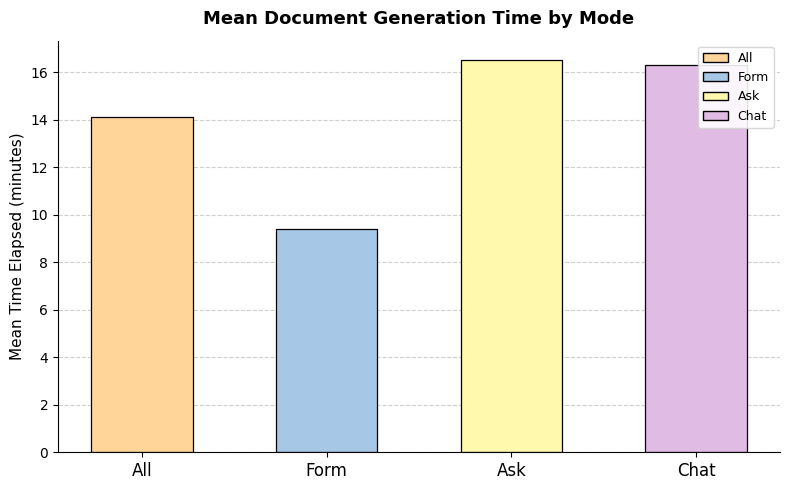

Saved → output/duration_by_mode.png


In [77]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# ── Extract Mode and Time elapsed from each document ─────────────────────────
# Each document contains a trailing metadata block with lines like:
#   Mode: chat
#   Time elapsed: 589 seconds

_elapsed_re = re.compile(r"Time elapsed:\s*(\d+)\s*seconds", re.IGNORECASE)

def extract_elapsed(text: str):
    m = _elapsed_re.search(str(text))
    return int(m.group(1)) if m else None

df_dur = df_all.copy()
df_dur["elapsed_sec"] = df_dur["document"].apply(extract_elapsed)

missing = df_dur["elapsed_sec"].isna().sum()
if missing:
    print(f"Warning: {missing} document(s) had no parseable 'Time elapsed' line — excluded.")
df_dur = df_dur.dropna(subset=["elapsed_sec"]).copy()

df_dur["elapsed_min"] = df_dur["elapsed_sec"] / 60
df_dur["mode_label"]  = df_dur["ai_mode"].str.strip().str.title()

# ── Summary table ─────────────────────────────────────────────────────────────
MODE_ORDER = ["Form", "Ask", "Chat"]
rows   = []
groups = {}

for label in MODE_ORDER:
    vals = df_dur[df_dur["mode_label"] == label]["elapsed_min"]
    groups[label] = vals
    rows.append({
        "Mode":       label,
        "n":          int(vals.count()),
        "Mean (min)": round(vals.mean(), 2),
        "Std":        round(vals.std(),  2),
        "Min (min)":  round(vals.min(),  2),
        "Max (min)":  round(vals.max(),  2),
    })

all_vals = df_dur["elapsed_min"]
rows.append({
    "Mode":       "All",
    "n":          int(all_vals.count()),
    "Mean (min)": round(all_vals.mean(), 2),
    "Std":        round(all_vals.std(),  2),
    "Min (min)":  round(all_vals.min(),  2),
    "Max (min)":  round(all_vals.max(),  2),
})

df_dur_summary = pd.DataFrame(rows).set_index("Mode")
print("Document Generation Time by Mode (minutes)")
display(df_dur_summary)

# ── Bar chart ─────────────────────────────────────────────────────────────────
GROUPS_ORDER = ["All",     "Form",    "Ask",     "Chat"]
BAR_COLORS   = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]

means_plot = [all_vals.mean()] + [groups[m].mean() for m in ["Form", "Ask", "Chat"]]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(GROUPS_ORDER))

ax.bar(
    x, means_plot,
    color=BAR_COLORS,
    edgecolor="black",
    linewidth=0.9,
    width=0.55,
)

ax.set_xticks(x)
ax.set_xticklabels(GROUPS_ORDER, fontsize=12)
ax.set_ylabel("Mean Time Elapsed (minutes)", fontsize=11)
ax.set_title("Mean Document Generation Time by Mode", fontsize=13, fontweight="bold", pad=12)
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend_handles = [
    mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
    for g, bc in zip(GROUPS_ORDER, BAR_COLORS)
]
ax.legend(handles=legend_handles, fontsize=9, framealpha=0.88,
          edgecolor="lightgrey", loc="upper right")

plt.tight_layout()
OUT = "output"
fname_dur = f"{OUT}/duration_by_mode.png"
plt.savefig(fname_dur, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_dur}")

## Per-Document Summaries

In [78]:
# ── Export: doc_nlp_summary.csv & doc_bert_summary.csv ──────────────────────
# Tidy per-metric summaries (n/min/q1/median/q3/max/mean/std + best/worst)
# across All, form, ask, chat groups, sourced from document_results.csv.

import pandas as pd

OUT = "output"

df_eval = pd.read_csv(f"{OUT}/document_results.csv")

NLP_METRICS  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
BERT_METRICS = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                "SBERT_ModernBERT"]


def build_doc_summary(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """
    For each metric compute descriptive stats + best/worst user_id across
    All rows and per-mode subsets.  Returns a wide DataFrame (rows = metrics).
    """
    groups = {"All": df, "form": df[df["ai_mode"] == "form"],
              "ask":  df[df["ai_mode"] == "ask"],
              "chat": df[df["ai_mode"] == "chat"]}

    rows = []
    for metric in metrics:
        row = {"metric": metric}
        for grp_name, grp_df in groups.items():
            s = grp_df[metric]
            prefix = grp_name
            row[f"{prefix}_n"]          = int(s.count())
            row[f"{prefix}_min"]        = round(s.min(),  4)
            row[f"{prefix}_q1"]         = round(s.quantile(0.25), 4)
            row[f"{prefix}_median"]     = round(s.median(), 4)
            row[f"{prefix}_q3"]         = round(s.quantile(0.75), 4)
            row[f"{prefix}_max"]        = round(s.max(),  4)
            row[f"{prefix}_mean"]       = round(s.mean(), 4)
            row[f"{prefix}_std"]        = round(s.std(),  4)
            row[f"{prefix}_best_id"]    = grp_df.loc[grp_df[metric].idxmax(), "user_id"]
            row[f"{prefix}_best_score"] = round(grp_df[metric].max(), 4)
            row[f"{prefix}_worst_id"]   = grp_df.loc[grp_df[metric].idxmin(), "user_id"]
            row[f"{prefix}_worst_score"]= round(grp_df[metric].min(), 4)
        rows.append(row)
    return pd.DataFrame(rows)


df_doc_nlp  = build_doc_summary(df_eval, NLP_METRICS)
df_doc_bert = build_doc_summary(df_eval, BERT_METRICS)

df_doc_nlp.to_csv(f"{OUT}/doc_nlp_summary.csv",  index=False)
df_doc_bert.to_csv(f"{OUT}/doc_bert_summary.csv", index=False)

print(f"Saved {OUT}/doc_nlp_summary.csv  — {len(df_doc_nlp)} rows")
print(f"Saved {OUT}/doc_bert_summary.csv — {len(df_doc_bert)} rows")


Saved output/doc_nlp_summary.csv  — 5 rows
Saved output/doc_bert_summary.csv — 4 rows


In [ ]:
# ── Export: all_scores_combined.csv & mode_summary_all_metrics.csv ──────────────
# all_scores_combined.csv: one row per document, all NLP + judge metrics joined
# mode_summary_all_metrics.csv: mean/median/std/min/max per mode for all metrics
import pandas as pd
import numpy as np

OUT = "output"

# ── Load judge results and pivot to wide format ──────────────────────────────
judge_df = pd.read_csv(f"{OUT}/judge_results.csv")
judge_wide = judge_df.pivot_table(
    index=["id", "user_id", "ai_mode"],
    columns="metric",
    values="score",
    aggfunc="first"
).reset_index()
judge_wide.columns.name = None
judge_wide.rename(columns={
    "completeness":           "Completeness",
    "hallucination_inverse":  "Hallucination_inverse",
    "legal_correctness":      "Legal_correctness",
    "overall":                "Overall",
    "scenario_faithfulness":  "Scenario_faithfulness",
}, inplace=True)

# ── Merge NLP + judge ─────────────────────────────────────────────────────────
judge_cols = ["id", "Completeness", "Hallucination_inverse", "Legal_correctness", "Overall", "Scenario_faithfulness"]
combined = pd.merge(df_all, judge_wide[judge_cols], on="id", how="left")
combined.to_csv(f"{OUT}/all_scores_combined.csv", index=False)
print(f"Exported all_scores_combined.csv — {combined.shape[0]} rows × {combined.shape[1]} cols")

# ── Per-mode summary stats ────────────────────────────────────────────────────
metric_cols = [
    "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
    "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1", "SBERT_ModernBERT",
    "Completeness", "Hallucination_inverse", "Legal_correctness", "Overall", "Scenario_faithfulness",
]
rows = []
for mode in ["form", "ask", "chat"]:
    sub = combined[combined["ai_mode"] == mode]
    for m in metric_cols:
        if m in sub.columns:
            vals = sub[m].dropna()
            rows.append({
                "mode": mode, "metric": m,
                "n":      len(vals),
                "mean":   round(vals.mean(),   4),
                "median": round(vals.median(), 4),
                "std":    round(vals.std(),    4),
                "min":    round(vals.min(),    4),
                "max":    round(vals.max(),    4),
            })
mode_summary = pd.DataFrame(rows)
mode_summary.to_csv(f"{OUT}/mode_summary_all_metrics.csv", index=False)
print(f"Exported mode_summary_all_metrics.csv — {mode_summary.shape[0]} rows")

In [79]:
# ── Display A: per-doc NLP + BERT summaries (one mode at a time) ─────────────
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

OUT = "output"
df_doc_nlp_disp  = pd.read_csv(f"{OUT}/doc_nlp_summary.csv")
df_doc_bert_disp = pd.read_csv(f"{OUT}/doc_bert_summary.csv")

NLP_METRICS_DISP  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
BERT_METRICS_DISP = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                     "SBERT_ModernBERT"]
STAT_COLS = ["n", "min", "q1", "median", "q3", "max", "mean", "std",
             "best_id", "best_score", "worst_id", "worst_score"]

for mode in ["All", "form", "ask", "chat"]:
    print(f"── {mode} ──")

    # NLP table
    nlp_cols = [f"{mode}_{s}" for s in STAT_COLS]
    df_nlp_view = df_doc_nlp_disp[df_doc_nlp_disp["metric"].isin(NLP_METRICS_DISP)].copy()
    df_nlp_view = df_nlp_view.set_index("metric")[nlp_cols]
    df_nlp_view.columns = STAT_COLS
    df_nlp_view = df_nlp_view.reset_index()
    display(df_nlp_view)

    # BERT table
    bert_cols = [f"{mode}_{s}" for s in STAT_COLS]
    df_bert_view = df_doc_bert_disp[df_doc_bert_disp["metric"].isin(BERT_METRICS_DISP)].copy()
    df_bert_view = df_bert_view.set_index("metric")[bert_cols]
    df_bert_view.columns = STAT_COLS
    df_bert_view = df_bert_view.reset_index()
    display(df_bert_view)


── All ──


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,113,0.0469,0.0938,0.1276,0.1593,0.2463,0.1330,0.0480,IOL1223,0.2463,PVV2109,0.0469
1,ROUGE-1,113,0.3131,0.4251,0.4906,0.5602,0.6446,0.4883,0.0872,EHN0215,0.6446,Jer1205,0.3131
2,ROUGE-2,113,0.1206,0.2344,0.2683,0.3440,0.4549,0.2848,0.0769,aea2442,0.4549,PVV2109,0.1206
3,ROUGE-L,113,0.1944,0.3112,0.3593,0.4410,0.5656,0.3751,0.0874,aea2442,0.5656,PVV2109,0.1944
4,METEOR,113,0.2336,0.3590,0.3877,0.4309,0.5142,0.3892,0.0615,EHN0215,0.5142,OAZ2611,0.2336


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BERTScore_Precision,113,0.8609,0.8801,0.8908,0.8998,0.9219,0.8902,0.0144,IOL1223,0.9219,thg1620,0.8609
1,BERTScore_Recall,113,0.8614,0.9139,0.9181,0.9222,0.9355,0.9146,0.0140,EII0925,0.9355,DAB1519,0.8614
2,BERTScore_F1,113,0.8629,0.8946,0.9038,0.9095,0.9219,0.9021,0.0114,EHN0215,0.9219,thg1620,0.8629
3,SBERT_ModernBERT,113,0.9705,0.9850,0.9883,0.9903,0.9936,0.9874,0.0040,NAN277,0.9936,thg1620,0.9705


── form ──


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,37,0.0638,0.0879,0.1236,0.1583,0.2297,0.1286,0.0475,aea2442,0.2297,Jer1205,0.0638
1,ROUGE-1,37,0.3131,0.4214,0.4932,0.5686,0.6441,0.4876,0.0982,NNL2811,0.6441,Jer1205,0.3131
2,ROUGE-2,37,0.1784,0.2411,0.3014,0.3611,0.4549,0.3060,0.0762,aea2442,0.4549,Jer1205,0.1784
3,ROUGE-L,37,0.2380,0.3195,0.3907,0.4676,0.5656,0.3880,0.0937,aea2442,0.5656,IHB1316,0.2380
4,METEOR,37,0.3348,0.3668,0.4186,0.4416,0.5142,0.4124,0.0505,EHN0215,0.5142,Jer1205,0.3348


...

,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,37,0.0469,0.0828,0.1245,0.1479,0.2463,0.1269,0.0560,IOL1223,0.2463,PVV2109,0.0469
1,ROUGE-1,37,0.3219,0.4124,0.4486,0.5219,0.6176,0.4654,0.0876,AHR0531,0.6176,DLZ2800,0.3219
2,ROUGE-2,37,0.1206,0.1997,0.2381,0.2750,0.4287,0.2568,0.0795,IOL1223,0.4287,PVV2109,0.1206
3,ROUGE-L,37,0.1944,0.2963,0.3259,0.3764,0.5452,0.3474,0.0913,IOL1223,0.5452,PVV2109,0.1944
4,METEOR,37,0.2336,0.3270,0.3658,0.4086,0.4880,0.3650,0.0681,IOL1223,0.4880,OAZ2611,0.2336


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BERTScore_Precision,37,0.8609,0.8723,0.8885,0.8994,0.9179,0.8861,0.0161,IOL1223,0.9179,thg1620,0.8609
1,BERTScore_Recall,37,0.8614,0.9075,0.9145,0.9181,0.9253,0.9082,0.0171,AMR2620,0.9253,DAB1519,0.8614
2,BERTScore_F1,37,0.8629,0.8922,0.8955,0.9055,0.9180,0.8969,0.0131,IOL1223,0.9180,thg1620,0.8629
3,SBERT_ModernBERT,37,0.9705,0.9832,0.9871,0.9898,0.9926,0.9862,0.0047,IOL1223,0.9926,thg1620,0.9705


── chat ──


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BLEU,39,0.0668,0.1216,0.1341,0.1631,0.2351,0.1430,0.0390,IOL1223,0.2351,aal1412,0.0668
1,ROUGE-1,39,0.3303,0.4682,0.5173,0.5608,0.6446,0.5106,0.0705,EHN0215,0.6446,aal1412,0.3303
2,ROUGE-2,39,0.1310,0.2526,0.2832,0.3443,0.4471,0.2913,0.0685,EHN0215,0.4471,PVV2109,0.1310
3,ROUGE-L,39,0.2304,0.3479,0.3868,0.4443,0.5443,0.3892,0.0721,EHN0215,0.5443,aal1412,0.2304
4,METEOR,39,0.2352,0.3741,0.3885,0.4211,0.5012,0.3902,0.0571,EHN0215,0.5012,PVV2109,0.2352


,metric,n,min,q1,median,q3,max,mean,std,best_id,best_score,worst_id,worst_score
0,BERTScore_Precision,39,0.8670,0.8900,0.8958,0.9019,0.9219,0.8954,0.0117,IOL1223,0.9219,PVV2109,0.8670
1,BERTScore_Recall,39,0.8737,0.9076,0.9167,0.9218,0.9329,0.9130,0.0132,EHN0215,0.9329,EHJ2314,0.8737
2,BERTScore_F1,39,0.8719,0.8992,0.9064,0.9105,0.9219,0.9041,0.0101,EHN0215,0.9219,PVV2109,0.8719
3,SBERT_ModernBERT,39,0.9850,0.9880,0.9901,0.9912,0.9936,0.9895,0.0022,NAN277,0.9936,EHJ2314,0.9850


## Visualisation — Per-Metric Boxplots

One boxplot per metric (BLEU · ROUGE-1/2/L · METEOR · BERTScore Recall · SBERT Similarity), comparing distributions across AI generation modes.

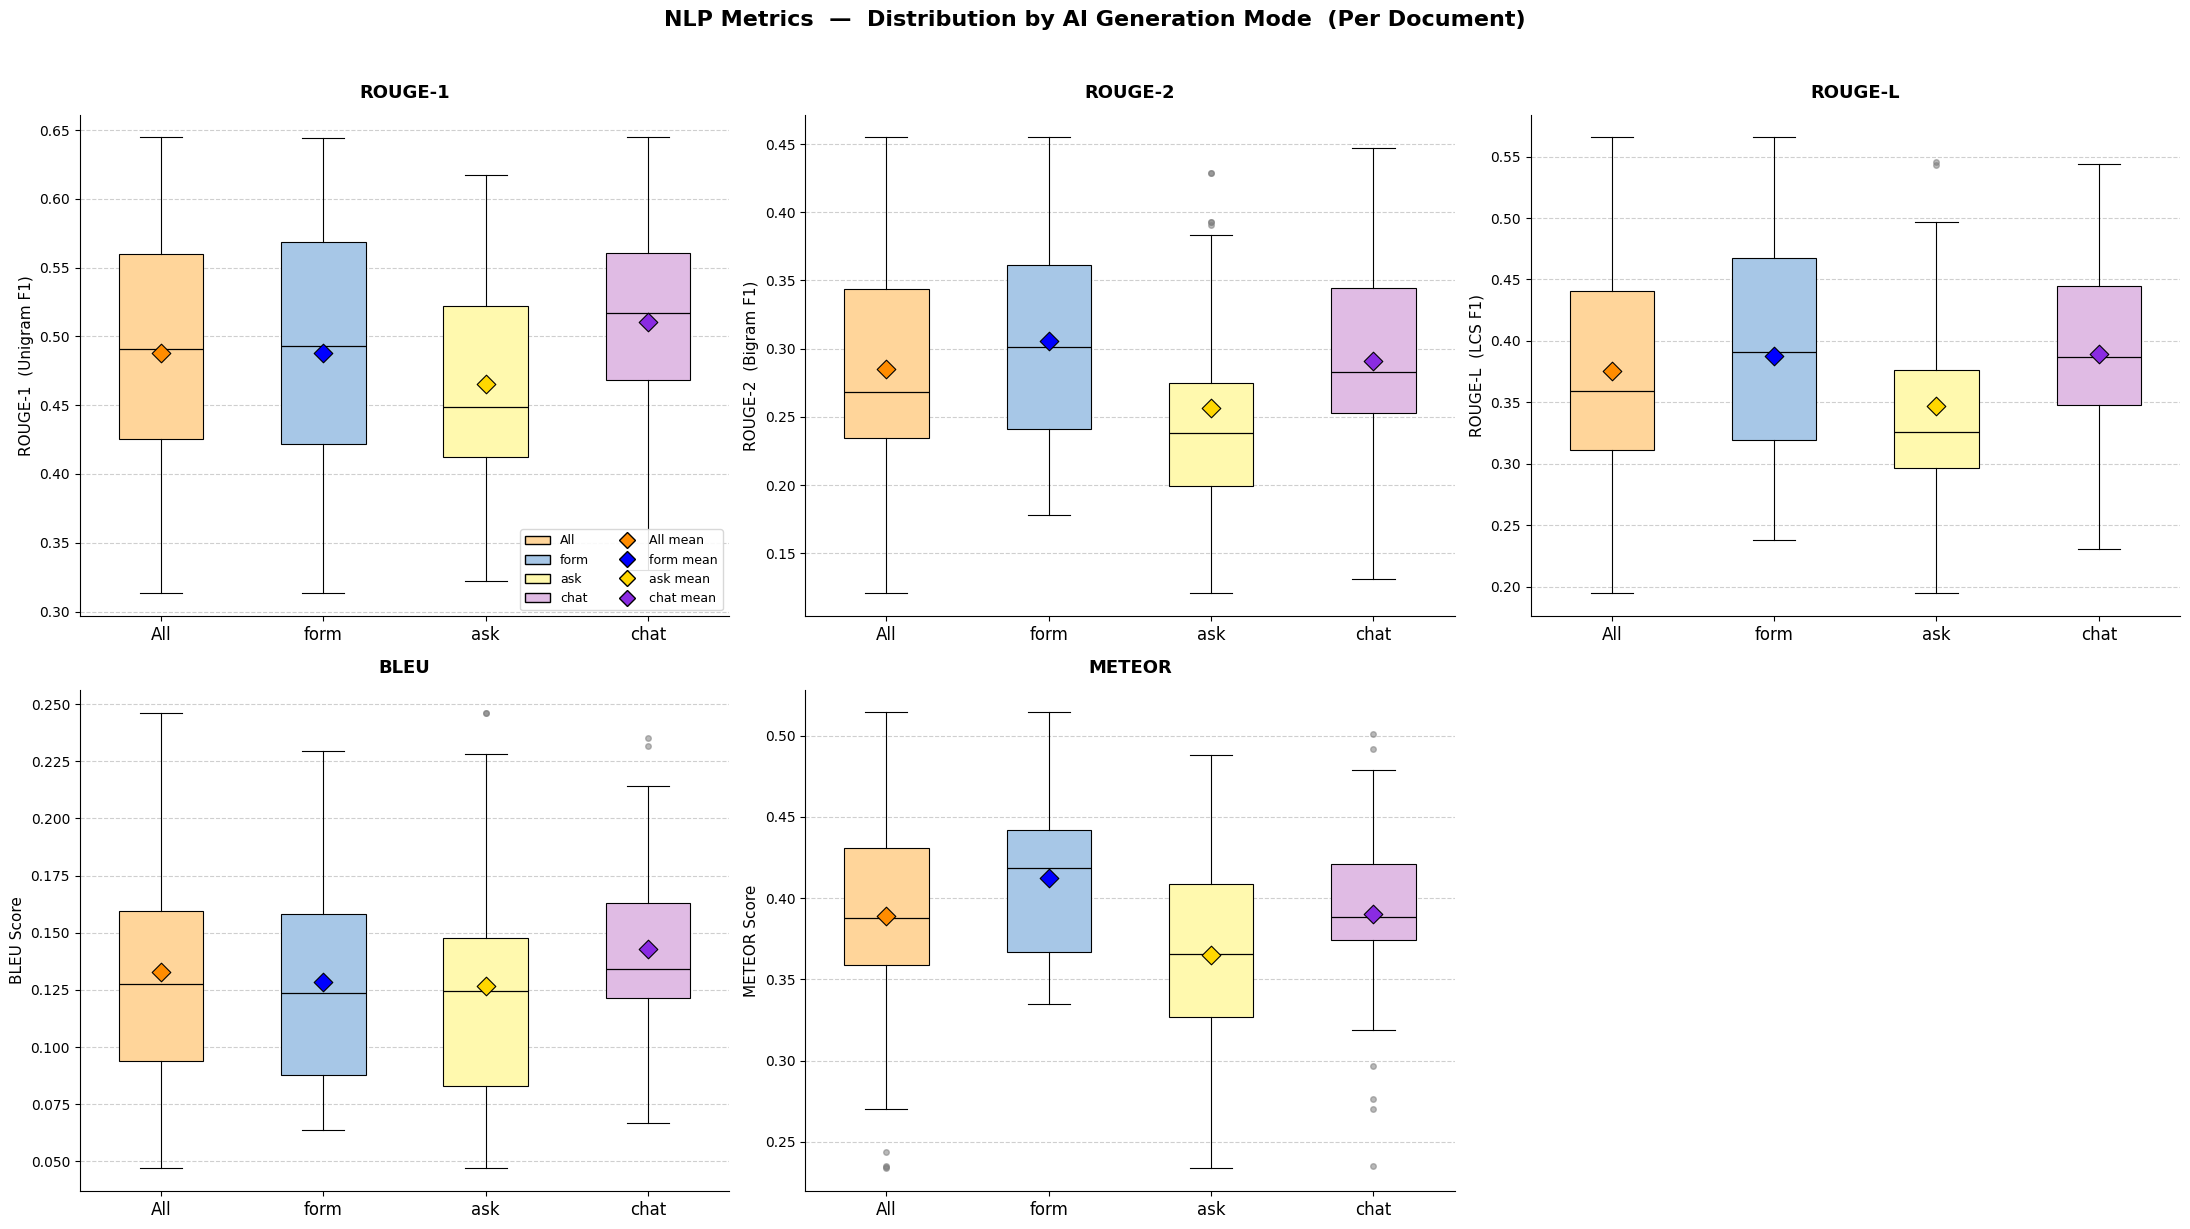

Saved → output/nlp_metrics_boxplot.png


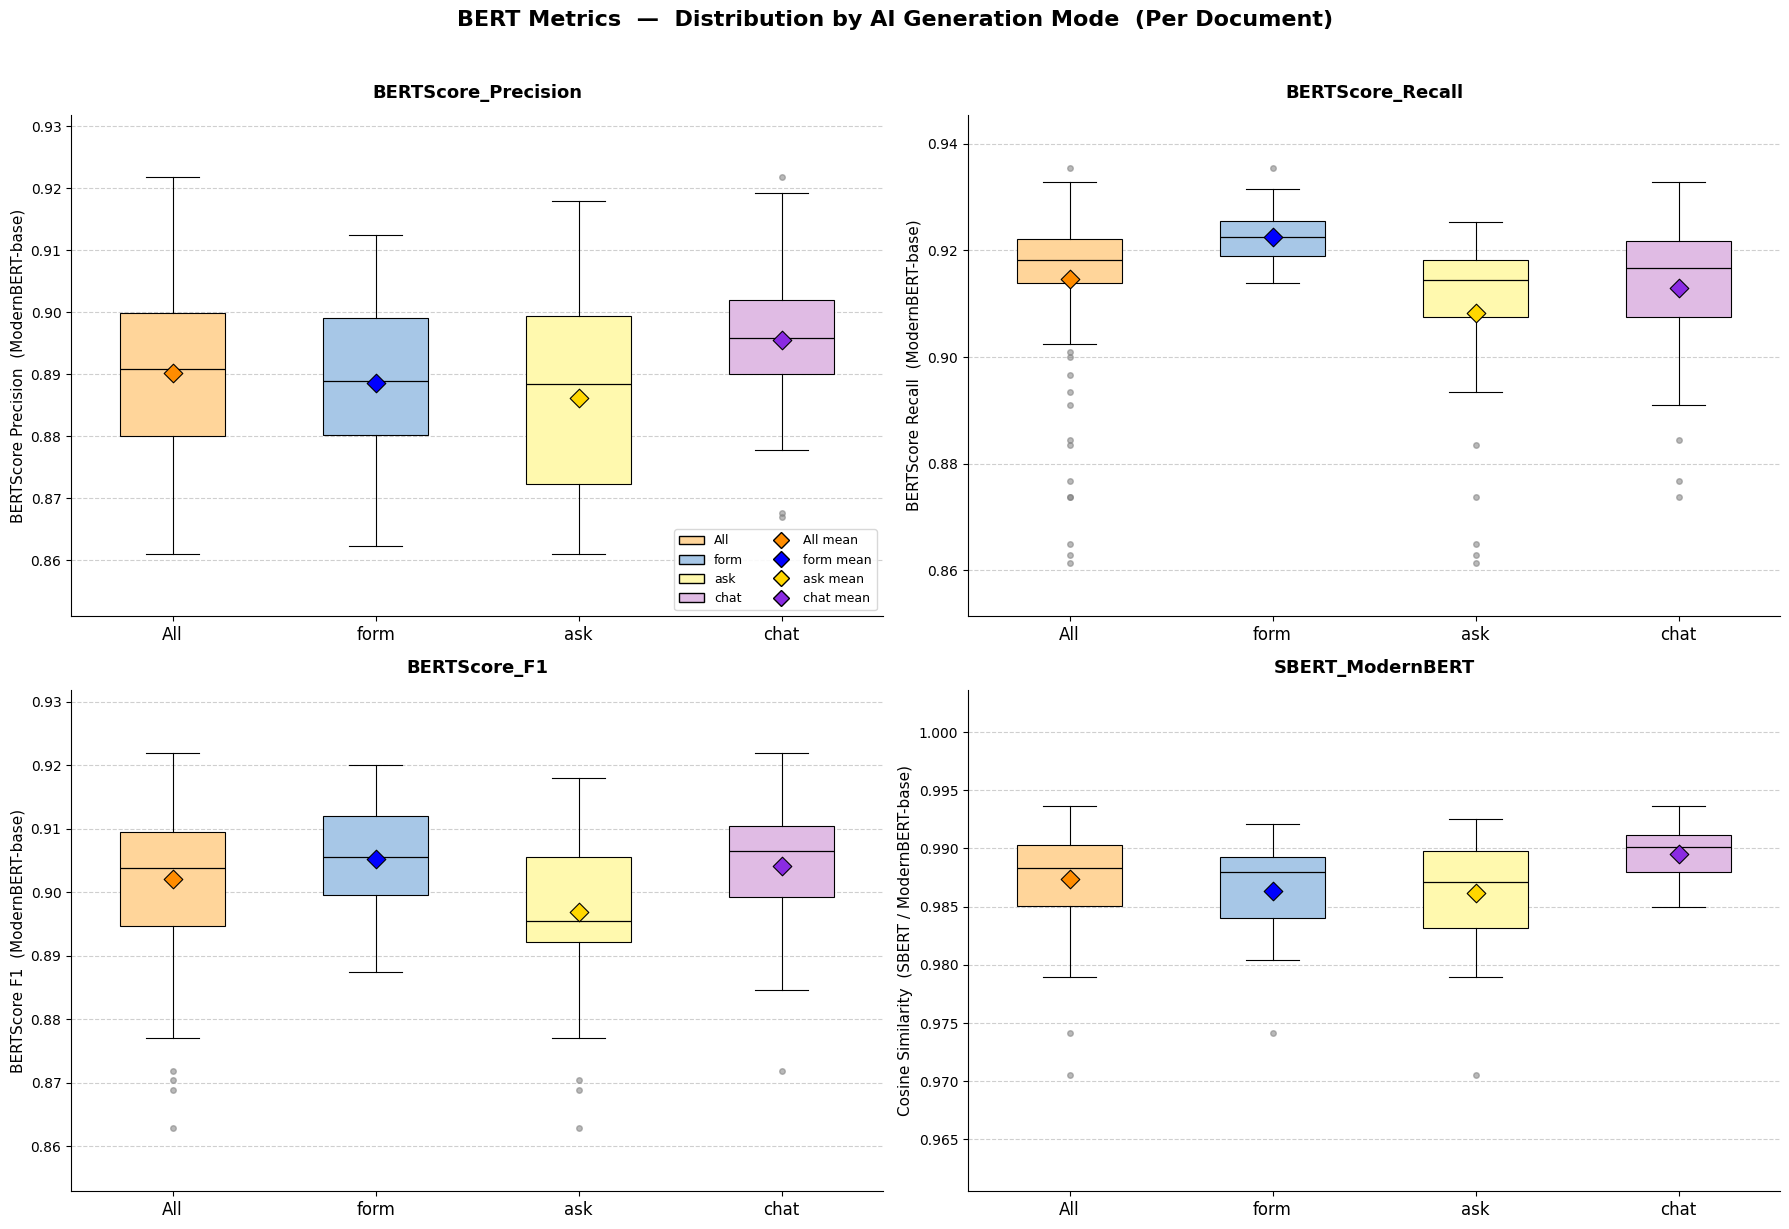

Saved → output/bert_metrics_boxplot.png


In [80]:
# ── Per-metric boxplots ────────────────────────────────────────────────────────
OUT = "output"

METRIC_META = [
    ("ROUGE-1",              "ROUGE-1  (Unigram F1)",                     (0.0, 1.0)),
    ("ROUGE-2",              "ROUGE-2  (Bigram F1)",                      (0.0, 1.0)),
    ("ROUGE-L",              "ROUGE-L  (LCS F1)",                         (0.0, 1.0)),
    ("BLEU",                 "BLEU Score",                                    None),
    ("METEOR",               "METEOR Score",                                   (0.0, 1.0)),
    ("BERTScore_Precision",  "BERTScore Precision  (ModernBERT-base)",        (0.85, 1.00)),
    ("BERTScore_Recall",     "BERTScore Recall  (ModernBERT-base)",           (0.85, 1.00)),
    ("BERTScore_F1",         "BERTScore F1  (ModernBERT-base)",               (0.85, 1.00)),
    ("SBERT_ModernBERT",     "Cosine Similarity  (SBERT / ModernBERT-base)",  (0.85, 1.00)),
]

NLP_METRICS  = METRIC_META[:5]   # BLEU, ROUGE-1/2/L, METEOR
BERT_METRICS = METRIC_META[5:]   # BERTScore P/R/F1, SBERT

GROUPS      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]

#
def _get_metric(metric: str, mode_key: str) -> np.ndarray:
    if mode_key == "All":
        return df_combined[metric].dropna().values
    df_m = mode_results.get(mode_key)
    if df_m is None or df_m.empty:
        return np.array([])
    return df_m[metric].dropna().values


def _draw_metric(ax, metric, ylabel, ylim, add_legend=False):
    group_data = [_get_metric(metric, g) for g in GROUPS]

    bp = ax.boxplot(
        group_data,
        positions=range(len(GROUPS)),
        widths=0.52,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=0.9),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        boxprops=dict(linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markeredgecolor="grey", markersize=4, alpha=0.55),
    )

    for patch, box_col in zip(bp["boxes"], BOX_COLORS):
        patch.set_facecolor(box_col)
        patch.set_edgecolor("black")

    for i, (data, mean_col) in enumerate(zip(group_data, MEAN_COLORS)):
        if len(data) == 0:
            continue
        ax.scatter(i, np.mean(data), marker="D", s=90,
                   color=mean_col, edgecolors="black", linewidths=0.8, zorder=6)

    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels(GROUPS, fontsize=12)

    # Dynamic y-axis limits based on actual data range
    all_vals = np.concatenate([d for d in group_data if len(d) > 0])
    if len(all_vals) > 0:
        data_min, data_max = all_vals.min(), all_vals.max()
        data_range = data_max - data_min
        padding = max(data_range * 0.05, 0.01)
        ax.set_ylim(data_min - padding, data_max + padding)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight="bold", pad=12)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
        for g, bc in zip(GROUPS, BOX_COLORS)
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor=mc, markeredgecolor="black",
                   markersize=8, label=f"{g} mean")
        for g, mc in zip(GROUPS, MEAN_COLORS)
    ]
    if add_legend:
        ax.legend(handles=box_patches + mean_handles, loc="lower right",
                  fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")


# ── PNG 1: NLP Metrics (BLEU · ROUGE-1/2/L · METEOR) — 2×3 grid ───────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(NLP_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

fig.delaxes(axes[5])  # remove 6th empty slot

plt.suptitle("NLP Metrics  —  Distribution by AI Generation Mode  (Per Document)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_nlp = f"{OUT}/nlp_metrics_boxplot.png"
plt.savefig(fname_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_nlp}")


# ── PNG 2: BERT Metrics (Precision · Recall · F1 · SBERT) — 2×2 grid ──────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (metric, ylabel, ylim) in enumerate(BERT_METRICS):
    _draw_metric(axes[i], metric, ylabel, ylim, add_legend=(i == 0))

plt.suptitle("BERT Metrics  —  Distribution by AI Generation Mode  (Per Document)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
fname_bert = f"{OUT}/bert_metrics_boxplot.png"
plt.savefig(fname_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {fname_bert}")


In [ ]:
# ── Per-metric doc-level boxplots: one PNG per metric ──────────────────────
# Splits the multi-panel nlp_metrics_boxplot.png (5 lexical) and
# bert_metrics_boxplot.png (4 BERT-based) figures into 9 standalone PNGs.
# Re-uses _draw_metric / _get_metric / GROUPS / BOX_COLORS / MEAN_COLORS from
# the multi-panel cell above. n = 113 documents (Form/Ask/Chat ~ 37 each).

DOC_NLP_FILES = {
    "BLEU":     "nlp_doc_bleu.png",
    "ROUGE-1":  "nlp_doc_rouge1.png",
    "ROUGE-2":  "nlp_doc_rouge2.png",
    "ROUGE-L":  "nlp_doc_rougeL.png",
    "METEOR":   "nlp_doc_meteor.png",
}
DOC_BERT_FILES = {
    "BERTScore_Precision": "nlp_doc_bertscore_p.png",
    "BERTScore_Recall":    "nlp_doc_bertscore_r.png",
    "BERTScore_F1":        "nlp_doc_bertscore_f1.png",
    "SBERT_ModernBERT":    "nlp_doc_sbert.png",
}

# Lexical metrics (n=113 docs per metric across modes)
for metric, ylabel, ylim in NLP_METRICS:
    fig, ax = plt.subplots(figsize=(6.0, 4.8))
    _draw_metric(ax, metric, ylabel, ylim, add_legend=True)
    fname = f"{OUT}/{DOC_NLP_FILES[metric]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved → {fname}")

# BERT / SBERT metrics
for metric, ylabel, ylim in BERT_METRICS:
    fig, ax = plt.subplots(figsize=(6.0, 4.8))
    _draw_metric(ax, metric, ylabel, ylim, add_legend=True)
    fname = f"{OUT}/{DOC_BERT_FILES[metric]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved → {fname}")


## Chapterwise Analysis

Each AI-generated document is split into its 6 canonical GDPR ROPA chapters and scored against the corresponding reference chapter. This reveals which parts of the ROPA structure participants handled well vs. poorly across the three interaction modes.

**6 canonical chapters (German):**
1. Verantwortliche Stelle und Kontaktdaten
2. Zwecke und Rechtsgrundlagen der Verarbeitung
3. Kategorien personenbezogener Daten und Datenquellen
4. Betroffene Personen und Empfänger
5. Aufbewahrungsfristen und Löschung
6. Technische und organisatorische Maßnahmen

In [ ]:
import re
import difflib

CANONICAL_CHAPTERS = [
    "Verantwortliche Stelle und Kontaktdaten",
    "Zwecke und Rechtsgrundlagen der Verarbeitung",
    "Kategorien personenbezogener Daten und Datenquellen",
    "Betroffene Personen und Empfänger",
    "Aufbewahrungsfristen und Löschung",
    "Technische und organisatorische Maßnahmen",
]

CH_SHORT = [f"Ch{i+1}" for i in range(len(CANONICAL_CHAPTERS))]
CH_LABEL = dict(zip(CANONICAL_CHAPTERS, CH_SHORT))

# Accepted surface forms (normalised: lowercased, leading numbering stripped,
# whitespace collapsed) for each canonical chapter. Add new variants here when
# new participant header phrasings are observed.
CHAPTER_ALIASES: dict[str, list[str]] = {
    "Verantwortliche Stelle und Kontaktdaten": [
        "verantwortliche stelle und kontaktdaten",
        "verantwortliche stelle und datenschutzbeauftragte",
        "verantwortliche stelle und datenschutzbeauftragter",
    ],
    "Zwecke und Rechtsgrundlagen der Verarbeitung": [
        "zwecke und rechtsgrundlagen der verarbeitung",
        "zwecke der verarbeitung und rechtsgrundlagen",
    ],
    "Kategorien personenbezogener Daten und Datenquellen": [
        "kategorien personenbezogener daten und datenquellen",
        "kategorien personenbezogener daten",
    ],
    "Betroffene Personen und Empfänger": [
        "betroffene personen und empfänger",
        "betroffene personen und empfänger der daten",
        "betroffene personen und empfänger:innen der daten",
    ],
    "Aufbewahrungsfristen und Löschung": [
        "aufbewahrungsfristen und löschung",
        "löschfristen und aufbewahrungsdauern",     # reference uses this variant
        "löschfristen und aufbewahrungsfristen",
        "löschfristen und datenaufbewahrung",
        "löschfristen und speicherdauer",
        "aufbewahrungsfristen und datenlöschung",
    ],
    "Technische und organisatorische Maßnahmen": [
        "technische und organisatorische maßnahmen",
        "technische und organisatorische maßnahmen (tom)",
        "technische und organisatorische massnahmen",
    ],
}


_SUBSECTION_RE = re.compile(r"^\s*\d+\.\d+")        # e.g. '2.1 Verarbeitungszwecke'
_LEADING_NUMBER_RE = re.compile(r"^\d+\.?\s+")      # e.g. '1. ', '1 '


def _normalize_header(line: str) -> str:
    """Strip a single leading top-level numbering ('1.', '1 '), lowercase, collapse whitespace.

    Subsection labels like '2.1 Verarbeitungszwecke' are intentionally NOT
    stripped here — they should never match a chapter alias, and are filtered
    out separately by `_match_canonical` before any matching.
    """
    s = line.strip()
    s = _LEADING_NUMBER_RE.sub("", s, count=1)
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s


def _match_canonical(line: str) -> str | None:
    """
    Return the canonical chapter for *line* if it matches a known header alias
    (case-/whitespace-/numbering-insensitive); else None.

    Hard guards (applied first):
      - Subsection lines (matching `^\\d+\\.\\d+`, e.g. '2.1 Verarbeitungszwecke')
        are NEVER treated as chapter headers — they are sub-section labels.
      - Lines containing a colon (':') are NEVER treated as headers; canonical
        section headers in the reference and in participant markdown never end
        with a colon, but many false-positive body lines do (e.g.
        'Wir verarbeiten personenbezogene Daten für folgende Zwecke:').

    Matching rules (in order):
      1. Exact match against any alias for any canonical chapter.
      2. The line *starts with* an alias and has at most 8 extra trailing
         characters (catches suffixes like ' (TOM)').
      3. Strict fuzzy match (SequenceMatcher ratio >= 0.92).
    """
    raw = line.strip()
    if not raw:
        return None
    if _SUBSECTION_RE.match(raw):
        return None
    if ":" in raw:
        return None

    norm = _normalize_header(raw)
    if not norm:
        return None
    for canonical, aliases in CHAPTER_ALIASES.items():
        for alias in aliases:
            if norm == alias:
                return canonical
            if norm.startswith(alias) and (len(norm) - len(alias)) <= 8:
                return canonical
        best = max(
            (difflib.SequenceMatcher(None, norm, a).ratio() for a in aliases),
            default=0.0,
        )
        if best >= 0.92:
            return canonical
    return None


def _is_sub_chapter(header: str) -> bool:
    """True for sub-chapter headings like '3.2 Datenquellen'."""
    return bool(_SUBSECTION_RE.match(header.strip()))


def _strip_metadata_footer(text: str) -> str:
    """Drop the trailing User ID / Mode / Time elapsed metadata block."""
    lines = text.split("\n")
    for i in range(len(lines) - 1, -1, -1):
        if lines[i].strip() == "---":
            return "\n".join(lines[:i])
    return text


def extract_chapters_markdown(text: str) -> dict[str, str]:
    """
    Split a markdown ROPA document into its H2 sections.

    Steps:
      1. Strip code-fence wrappers (```markdown ... ```).
      2. Remove the metadata footer (lines after the last '---' separator).
      3. Find all ``## ...`` headings, skipping sub-chapter headings like '3.2 ...'.
      4. Return {raw_header: section_content} preserving document order.
    """
    text = text.strip()
    if text.startswith("```"):
        text = text[text.index("\n") + 1:]
    if text.endswith("```"):
        text = text[:text.rindex("```")]
    text = _strip_metadata_footer(text)

    pattern = re.compile(r"^## (.+)", re.MULTILINE)
    matches = [
        m for m in pattern.finditer(text)
        if not _is_sub_chapter(m.group(1).strip())
    ]

    chapters: dict[str, str] = {}
    for idx, match in enumerate(matches):
        header = match.group(1).strip()
        start  = match.end()
        end    = matches[idx + 1].start() if idx + 1 < len(matches) else len(text)
        chapters[header] = text[start:end].strip()
    return chapters


def extract_reference_chapters(
    reference_text: str,
    canonical_list: list[str] = CANONICAL_CHAPTERS,
) -> dict[str, str]:
    """
    Split the plain-text reference into the six canonical chapters.

    Strategy (explicit-list, not heuristic):
      1. Strip the metadata footer.
      2. Walk every line; treat a line as a chapter header *only* if it matches
         one of the known aliases in CHAPTER_ALIASES (via `_match_canonical`).
      3. The text between two matched header lines becomes that chapter's body.
         Sub-section labels ('2.1 Verarbeitungszwecke') are kept as content,
         not treated as headers — they never appear in CHAPTER_ALIASES.

    This replaces the previous heuristic ('short non-bullet line with fuzzy
    match at ratio 0.35') which mis-classified body lines like
    "Wir verarbeiten personenbezogene Daten für folgende Zwecke:" as headers,
    truncating Ch2/Ch3/Ch4 to their sub-section title strings only.
    """
    text = _strip_metadata_footer(reference_text)
    lines = text.split("\n")

    header_positions: list[tuple[int, str]] = []  # (line_index, canonical_name)
    for i, line in enumerate(lines):
        canonical = _match_canonical(line)
        if canonical is not None:
            header_positions.append((i, canonical))

    result: dict[str, str] = {c: "" for c in canonical_list}
    for idx, (line_i, canonical) in enumerate(header_positions):
        next_i = header_positions[idx + 1][0] if idx + 1 < len(header_positions) else len(lines)
        content_lines = lines[line_i + 1:next_i]
        # Last writer wins if a chapter header appears twice (it shouldn't)
        result[canonical] = "\n".join(content_lines).strip()
    return result


def map_doc_chapters_to_canonical(
    raw_dict: dict[str, str],
    canonical_list: list[str] = CANONICAL_CHAPTERS,
) -> dict[str, str]:
    """
    Map extracted participant-document chapters to canonical names.

    Two-stage strategy:
      1. Exact / alias match via `_match_canonical` — covers the common case
         where participant headers match a known variant (e.g. "Löschfristen
         und Speicherdauer" → "Aufbewahrungsfristen und Löschung").
      2. SequenceMatcher fallback at ratio >= 0.45 for any canonical chapters
         still unassigned, with positional fallback last. Threshold 0.45 was
         the previous behaviour and is left untouched for the fallback.

    Missing chapters (genuinely absent from the document) get empty string.
    """
    headers_in_order = list(raw_dict.keys())
    result: dict[str, str] = {}
    used_headers: set[str] = set()

    # Stage 1 — explicit alias matching
    for h in headers_in_order:
        canonical = _match_canonical(h)
        if canonical is not None and canonical not in result:
            result[canonical] = raw_dict[h]
            used_headers.add(h)

    # Stage 2 — fuzzy fallback (existing behaviour, kept for headers that
    # don't yet have an alias listed)
    for canonical in canonical_list:
        if canonical in result:
            continue
        best_score, best_header = 0.0, None
        for h in headers_in_order:
            if h in used_headers:
                continue
            h_clean = re.sub(r"^\d+[.,]?\d*[\s.]+", "", h).strip()
            ratio = difflib.SequenceMatcher(None, h_clean.lower(), canonical.lower()).ratio()
            if ratio > best_score:
                best_score, best_header = ratio, h
        if best_score >= 0.45 and best_header is not None:
            result[canonical] = raw_dict[best_header]
            used_headers.add(best_header)

    # Stage 3 — positional fallback
    unmatched_headers  = [h for h in headers_in_order if h not in used_headers]
    missing_canonicals = [c for c in canonical_list if c not in result]
    for i, canonical in enumerate(missing_canonicals):
        if i < len(unmatched_headers):
            result[canonical] = raw_dict[unmatched_headers[i]]
            used_headers.add(unmatched_headers[i])
        else:
            result[canonical] = ""  # genuinely missing chapter → score as 0

    return result


# ── Parse reference chapters once ─────────────────────────────────────────
ref_chapters = extract_reference_chapters(reference_text)
print("Reference chapters extracted:")
for ch in CANONICAL_CHAPTERS:
    content = ref_chapters.get(ch, "")
    n_lines = len(content.split("\n")) if content else 0
    first_line = content.split("\n")[0][:70] if content else "(empty)"
    print(f"  {CH_LABEL[ch]:>4} {ch[:55]:<55} {len(content):>4} chars / {n_lines:>2} lines  | {first_line!r}")


In [82]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch.nn.functional as F

# ── Load MiniLM (chapter-level only; NOT used for whole-document scoring) ──
MINILM_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Loading SentenceTransformer: {MINILM_NAME} …")
sbert_minilm = SentenceTransformer(MINILM_NAME, device=DEVICE)
sbert_minilm.max_seq_length = 384
print(f"Max seq length : {sbert_minilm.max_seq_length}")
print(f"Embedding dim  : {sbert_minilm.get_sentence_embedding_dimension()}")

# ── Pre-encode reference chapters with both models ─────────────────────────
ref_chapter_texts = [ref_chapters.get(ch, "") for ch in CANONICAL_CHAPTERS]

# ModernBERT (sbert_model already loaded in cell 6)
ref_ch_emb_modernbert = sbert_model.encode(
    ref_chapter_texts,
    batch_size=1,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (6, hidden_dim)

# MiniLM
ref_ch_emb_minilm = sbert_minilm.encode(
    ref_chapter_texts,
    batch_size=6,
    convert_to_numpy=True,
    normalize_embeddings=True,
    show_progress_bar=False,
)  # shape: (6, hidden_dim)

print(f"Reference chapter embeddings (ModernBERT): {ref_ch_emb_modernbert.shape}")
print(f"Reference chapter embeddings (MiniLM)    : {ref_ch_emb_minilm.shape}")


Loading SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12600.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 384
Embedding dim  : 384
Reference chapter embeddings (ModernBERT): (6, 768)
Reference chapter embeddings (MiniLM)    : (6, 384)


In [83]:
from tqdm.auto import tqdm
import torch

CHAPTER_METRIC_COLS = [
    "BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR",
    "BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
    "SBERT_ModernBERT", "SBERT_MiniLM",
]


def compute_chapter_metrics_for_doc(
    doc_chapters: dict[str, str],
    ref_ch_emb_mb: np.ndarray,
    ref_ch_emb_ml: np.ndarray,
) -> list[dict]:
    """
    Compute all metrics for one document's 6 canonical chapters.
    Returns a list of 6 dicts (one per chapter) with metric scores.
    """
    rows = []
    for ch_idx, canonical in enumerate(CANONICAL_CHAPTERS):
        cand_text = doc_chapters.get(canonical, "")
        ref_text  = ref_chapters.get(canonical, "")

        row = {"chapter": canonical}

        if not cand_text.strip() or not ref_text.strip():
            # Missing chapter → zero scores for all metrics
            for col in CHAPTER_METRIC_COLS:
                row[col] = 0.0
            rows.append(row)
            continue

        # ── Lexical metrics (reuse existing functions) ─────────────────────
        try:
            b = bleu_metric.compute(predictions=[cand_text], references=[[ref_text]])
            row["BLEU"] = b["bleu"]
        except Exception:
            row["BLEU"] = 0.0

        r = rouge_metric.compute(predictions=[cand_text], references=[ref_text])
        row["ROUGE-1"] = r["rouge1"]
        row["ROUGE-2"] = r["rouge2"]
        row["ROUGE-L"] = r["rougeL"]

        m = meteor_metric.compute(predictions=[cand_text], references=[ref_text])
        row["METEOR"] = m["meteor"]

        # ── BERTScore (ModernBERT, batch_size=1 for short chapter strings) ───
        prec_list, rec_list, f1_list = compute_bertscore(
            [cand_text], ref_text, batch_size=1
        )
        row["BERTScore_Precision"] = prec_list[0]
        row["BERTScore_Recall"]    = rec_list[0]
        row["BERTScore_F1"]        = f1_list[0]

        # ── SBERT ModernBERT ──────────────────────────────────────────────
        cand_emb_mb = sbert_model.encode(
            [cand_text],
            batch_size=1,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        )  # (1, dim)
        sim_mb = float((cand_emb_mb @ ref_ch_emb_mb[ch_idx:ch_idx+1].T).squeeze())
        row["SBERT_ModernBERT"] = sim_mb

        # ── SBERT MiniLM ─────────────────────────────────────────────────
        cand_emb_ml = sbert_minilm.encode(
            [cand_text],
            batch_size=1,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        )  # (1, dim)
        sim_ml = float((cand_emb_ml @ ref_ch_emb_ml[ch_idx:ch_idx+1].T).squeeze())
        row["SBERT_MiniLM"] = sim_ml

        rows.append(row)
    return rows


# ── Build lookup: id → document text (from df_all loaded in cell 2) ──────
_doc_lookup = df_all.set_index("id")["document"].to_dict()

# ── Run over all documents ─────────────────────────────────────────────────
all_chapter_rows = []

for _, doc_row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Documents"):
    doc_text     = str(_doc_lookup.get(doc_row["id"], ""))
    raw_chapters = extract_chapters_markdown(doc_text)
    doc_chapters = map_doc_chapters_to_canonical(raw_chapters)

    ch_rows = compute_chapter_metrics_for_doc(
        doc_chapters, ref_ch_emb_modernbert, ref_ch_emb_minilm
    )
    for ch_row in ch_rows:
        ch_row["id"]      = doc_row["id"]
        ch_row["user_id"] = doc_row["user_id"]
        ch_row["ai_mode"] = doc_row["ai_mode"]
        all_chapter_rows.append(ch_row)

df_chapters = pd.DataFrame(all_chapter_rows)[
    ["id", "user_id", "ai_mode", "chapter"] + CHAPTER_METRIC_COLS
]

df_chapters.to_csv(f"{OUT}/chapter_results.csv", index=False)
print(f"\nSaved {OUT}/chapter_results.csv  — {len(df_chapters)} rows")
print(f"Shape: {df_chapters.shape}")

Documents: 100%|██████████| 113/113 [01:28<00:00,  1.28it/s]


Saved output/chapter_results.csv  — 678 rows
Shape: (678, 14)


In [84]:
# ── Per-mode, per-chapter summary ────────────────────────────────────────

def build_chapter_summary(df: pd.DataFrame, metric_cols: list[str]) -> pd.DataFrame:
    """
    For each (ai_mode, chapter) group compute mean, std, best_id, worst_id
    for every metric.  Returns a tidy DataFrame.
    """
    rows = []
    for (mode, chapter), grp in df.groupby(["ai_mode", "chapter"], sort=False):
        row = {"ai_mode": mode, "chapter": chapter}
        for col in metric_cols:
            row[f"{col}_mean"] = grp[col].mean()
            row[f"{col}_std"]  = grp[col].std()
            row[f"{col}_best_id"]  = grp.loc[grp[col].idxmax(), "user_id"] if len(grp) > 0 else None
            row[f"{col}_worst_id"] = grp.loc[grp[col].idxmin(), "user_id"] if len(grp) > 0 else None
        rows.append(row)
    return pd.DataFrame(rows)


df_ch_summary_mode = build_chapter_summary(df_chapters, CHAPTER_METRIC_COLS)
# Ensure canonical chapter order
df_ch_summary_mode["chapter"] = pd.Categorical(
    df_ch_summary_mode["chapter"], categories=CANONICAL_CHAPTERS, ordered=True
)
df_ch_summary_mode = df_ch_summary_mode.sort_values(["ai_mode", "chapter"]).reset_index(drop=True)

# ── Aggregated chapter summary (across all modes) ────────────────────────

rows_overall = []
for chapter, grp in df_chapters.groupby("chapter", sort=False):
    row = {"chapter": chapter}
    for col in CHAPTER_METRIC_COLS:
        row[f"{col}_mean"] = grp[col].mean()
        row[f"{col}_std"]  = grp[col].std()
        row[f"{col}_best_id"]  = grp.loc[grp[col].idxmax(), "user_id"] if len(grp) > 0 else None
        row[f"{col}_worst_id"] = grp.loc[grp[col].idxmin(), "user_id"] if len(grp) > 0 else None
    rows_overall.append(row)

df_ch_summary_overall = pd.DataFrame(rows_overall)
df_ch_summary_overall["chapter"] = pd.Categorical(
    df_ch_summary_overall["chapter"], categories=CANONICAL_CHAPTERS, ordered=True
)
df_ch_summary_overall = df_ch_summary_overall.sort_values("chapter").reset_index(drop=True)




In [85]:
# ── Combined comparison: whole-document score vs. mean chapter score ─────
# Rows: each metric (+ SBERT_MiniLM as chapter-only)
# Columns: metric | doc_score (mean) | chapter_avg (mean of 6 chapter means) | difference

def build_comparison_table(
    df_doc: pd.DataFrame,
    df_ch: pd.DataFrame,
    label: str,
) -> pd.DataFrame:
    """Build doc-vs-chapter comparison for one subset (mode or all)."""
    records = []

    # Metrics that exist in both doc-level and chapter-level
    shared_metrics = [
        ("BLEU",               "BLEU"),
        ("ROUGE-1",            "ROUGE-1"),
        ("ROUGE-2",            "ROUGE-2"),
        ("ROUGE-L",            "ROUGE-L"),
        ("METEOR",             "METEOR"),
        ("BERTScore_Precision", "BERTScore_Precision"),
        ("BERTScore_Recall",   "BERTScore_Recall"),
        ("BERTScore_F1",       "BERTScore_F1"),
        ("SBERT_ModernBERT",   "SBERT_ModernBERT"),  # whole-doc SBERT vs chapter SBERT ModernBERT
    ]
    for doc_col, ch_col in shared_metrics:
        doc_mean = df_doc[doc_col].mean() if doc_col in df_doc.columns else float('nan')
        ch_mean  = df_ch[ch_col].mean()  if ch_col  in df_ch.columns  else float('nan')
        records.append({
            "subset":       label,
            "metric":       doc_col,
            "doc_score":    round(doc_mean, 4),
            "chapter_avg":  round(ch_mean,  4),
            "difference":   round(doc_mean - ch_mean, 4),
        })

    # SBERT_MiniLM — chapter-only (no whole-doc equivalent)
    if "SBERT_MiniLM" in df_ch.columns:
        records.append({
            "subset":      label,
            "metric":      "SBERT_MiniLM",
            "doc_score":   float('nan'),
            "chapter_avg": round(df_ch["SBERT_MiniLM"].mean(), 4),
            "difference":  float('nan'),
        })

    return pd.DataFrame(records)


MODES_ALL = sorted(df_eval["ai_mode"].unique())
comparison_parts = []

# Overall
comparison_parts.append(
    build_comparison_table(df_eval, df_chapters, label="overall")
)

# Per mode
for mode in MODES_ALL:
    comparison_parts.append(
        build_comparison_table(
            df_eval[df_eval["ai_mode"] == mode],
            df_chapters[df_chapters["ai_mode"] == mode],
            label=mode,
        )
    )

df_comparison = pd.concat(comparison_parts, ignore_index=True)
df_comparison_pivot = df_comparison.pivot(
    index="metric", columns="subset", values=["doc_score", "chapter_avg", "difference"]
)
df_comparison_T = df_comparison_pivot.T



In [86]:
# ── Export: chapter_nlp_summary.csv & chapter_bert_summary.csv ───────────────
# Tidy per-metric × per-chapter summaries (n/min/q1/median/q3/max/mean/std +
# best/worst) across All, form, ask, chat groups, from chapter_results.csv.

import pandas as pd

OUT = "output"

CANONICAL_CHAPTERS = [
    "Verantwortliche Stelle und Kontaktdaten",
    "Zwecke und Rechtsgrundlagen der Verarbeitung",
    "Kategorien personenbezogener Daten und Datenquellen",
    "Betroffene Personen und Empfänger",
    "Aufbewahrungsfristen und Löschung",
    "Technische und organisatorische Maßnahmen",
]
CH_LABELS = {ch: f"ch{i+1}" for i, ch in enumerate(CANONICAL_CHAPTERS)}

CH_NLP_METRICS  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
CH_BERT_METRICS = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                   "SBERT_ModernBERT", "SBERT_MiniLM"]

df_ch = pd.read_csv(f"{OUT}/chapter_results.csv")


def build_chapter_summary_tidy(df: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """
    Returns 30 rows (5 or 5 metrics × 6 chapters), wide stats per group.
    Column order: metric, chapter, then All_*/form_*/ask_*/chat_* stat columns.
    """
    groups = {"All": df, "form": df[df["ai_mode"] == "form"],
              "ask":  df[df["ai_mode"] == "ask"],
              "chat": df[df["ai_mode"] == "chat"]}

    rows = []
    for metric in metrics:
        for ch_full in CANONICAL_CHAPTERS:
            row = {"metric": metric, "chapter": CH_LABELS[ch_full]}
            for grp_name, grp_df in groups.items():
                s = grp_df.loc[grp_df["chapter"] == ch_full, metric]
                prefix = grp_name
                row[f"{prefix}_n"]          = int(s.count())
                row[f"{prefix}_min"]        = round(s.min(),  4)
                row[f"{prefix}_q1"]         = round(s.quantile(0.25), 4)
                row[f"{prefix}_median"]     = round(s.median(), 4)
                row[f"{prefix}_q3"]         = round(s.quantile(0.75), 4)
                row[f"{prefix}_max"]        = round(s.max(),  4)
                row[f"{prefix}_mean"]       = round(s.mean(), 4)
                row[f"{prefix}_std"]        = round(s.std(),  4)
                if len(s) > 0:
                    ch_grp = grp_df[grp_df["chapter"] == ch_full]
                    row[f"{prefix}_best_id"]    = ch_grp.loc[ch_grp[metric].idxmax(), "user_id"]
                    row[f"{prefix}_best_score"] = round(s.max(), 4)
                    row[f"{prefix}_worst_id"]   = ch_grp.loc[ch_grp[metric].idxmin(), "user_id"]
                    row[f"{prefix}_worst_score"]= round(s.min(), 4)
                else:
                    row[f"{prefix}_best_id"]    = None
                    row[f"{prefix}_best_score"] = None
                    row[f"{prefix}_worst_id"]   = None
                    row[f"{prefix}_worst_score"]= None
            rows.append(row)
    return pd.DataFrame(rows)


df_ch_nlp  = build_chapter_summary_tidy(df_ch, CH_NLP_METRICS)
df_ch_bert = build_chapter_summary_tidy(df_ch, CH_BERT_METRICS)

df_ch_nlp.to_csv(f"{OUT}/chapter_nlp_summary.csv",  index=False)
df_ch_bert.to_csv(f"{OUT}/chapter_bert_summary.csv", index=False)

print(f"Saved {OUT}/chapter_nlp_summary.csv  — {len(df_ch_nlp)} rows")
print(f"Saved {OUT}/chapter_bert_summary.csv — {len(df_ch_bert)} rows")



Saved output/chapter_nlp_summary.csv  — 30 rows
Saved output/chapter_bert_summary.csv — 30 rows


In [87]:
# ── Export: doc_vs_chapter_diff.csv ─────────────────────────────────────────
# For each metric × mode: diff = doc_mean - mean(chapter_means across ch1–ch6)
import pandas as pd

OUT = "output"

df_doc_nlp  = pd.read_csv(f"{OUT}/doc_nlp_summary.csv")
df_doc_bert = pd.read_csv(f"{OUT}/doc_bert_summary.csv")
df_ch_nlp   = pd.read_csv(f"{OUT}/chapter_nlp_summary.csv")
df_ch_bert  = pd.read_csv(f"{OUT}/chapter_bert_summary.csv")

# Combine doc summaries
df_doc_all = pd.concat([df_doc_nlp, df_doc_bert], ignore_index=True)

# Combine chapter summaries
df_ch_all  = pd.concat([df_ch_nlp, df_ch_bert], ignore_index=True)

MODES = ["All", "form", "ask", "chat"]

# Build result rows
rows = []
for metric in df_doc_all["metric"].unique():
    row = {"metric": metric}
    for mode in MODES:
        doc_row = df_doc_all[df_doc_all["metric"] == metric]
        doc_mean = doc_row[f"{mode}_mean"].values[0] if not doc_row.empty else None

        ch_rows = df_ch_all[df_ch_all["metric"] == metric]
        if not ch_rows.empty:
            ch_mean_avg = ch_rows[f"{mode}_mean"].mean()
        else:
            ch_mean_avg = None

        diff = (doc_mean - ch_mean_avg) if (doc_mean is not None and ch_mean_avg is not None) else None

        row[f"{mode}_doc"]          = doc_mean
        row[f"{mode}_chapter_mean"] = ch_mean_avg
        row[f"{mode}_diff"]         = diff
    rows.append(row)

df_diff = pd.DataFrame(rows)

# Order columns: metric, then for each mode: doc, chapter_mean, diff
col_order = ["metric"]
for mode in MODES:
    col_order += [f"{mode}_doc", f"{mode}_chapter_mean", f"{mode}_diff"]
df_diff = df_diff[col_order]

df_diff.to_csv(f"{OUT}/doc_vs_chapter_diff.csv", index=False)
print(f"Saved {OUT}/doc_vs_chapter_diff.csv  ({len(df_diff)} rows x {len(df_diff.columns)} cols)")


Saved output/doc_vs_chapter_diff.csv  (9 rows x 13 cols)


In [88]:
# ── Display B: per-chapter NLP + BERT + diff summaries (one mode at a time) ───
import pandas as pd
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

OUT = "output"
df_ch_nlp_disp  = pd.read_csv(f"{OUT}/chapter_nlp_summary.csv")
df_ch_bert_disp = pd.read_csv(f"{OUT}/chapter_bert_summary.csv")
df_diff_disp    = pd.read_csv(f"{OUT}/doc_vs_chapter_diff.csv")

CH_NLP_METRICS_DISP  = ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L", "METEOR"]
CH_BERT_METRICS_DISP = ["BERTScore_Precision", "BERTScore_Recall", "BERTScore_F1",
                         "SBERT_ModernBERT", "SBERT_MiniLM"]
CHAPTERS  = [f"ch{i+1}" for i in range(6)]
STAT_COLS = ["n", "min", "q1", "median", "q3", "max", "mean", "std",
             "best_id", "best_score", "worst_id", "worst_score"]

# Build a MultiIndex display table for one set of metrics + one mode
def build_chapter_multiindex(df_summary, metrics, mode):
    tuples = [(ch, stat) for ch in CHAPTERS for stat in STAT_COLS]
    mi = pd.MultiIndex.from_tuples(tuples, names=["chapter", "stat"])
    data = []
    for metric in metrics:
        subset = df_summary[df_summary["metric"] == metric].copy()
        subset = subset.set_index("chapter")
        row_vals = []
        for ch in CHAPTERS:
            for stat in STAT_COLS:
                col = f"{mode}_{stat}"
                if ch in subset.index and col in subset.columns:
                    row_vals.append(subset.loc[ch, col])
                else:
                    row_vals.append(None)
        data.append(row_vals)
    return pd.DataFrame(data, index=metrics, columns=mi)

# ── Per-mode tables first, then diff tables ────────────────────────────────
for mode in ["All", "form", "ask", "chat"]:
    print(f"\n── {mode} — NLP ──")
    display(build_chapter_multiindex(df_ch_nlp_disp, CH_NLP_METRICS_DISP, mode))

    print(f"\n── {mode} — BERT ──")
    display(build_chapter_multiindex(df_ch_bert_disp, CH_BERT_METRICS_DISP, mode))

# ── Diff tables last ────────────────────────────────────────────────────────
for mode in ["All", "form", "ask", "chat"]:
    print(f"\n── {mode} ── (diff: doc vs chapter)")
    diff_cols = [f"{mode}_doc", f"{mode}_chapter_mean", f"{mode}_diff"]
    df_diff_view = df_diff_disp[["metric"] + diff_cols].copy()
    df_diff_view.columns = ["metric", "doc_mean", "chapter_mean", "diff"]
    display(df_diff_view)



── All — NLP ──


chapter  ch1                                                                   \
stat       n     min      q1  median      q3     max    mean     std  best_id   
BLEU     113  0.0000  0.1320  0.1645  0.2391  0.3660  0.1811  0.0801  NIL1922   
ROUGE-1  113  0.1687  0.5167  0.5664  0.6250  0.8704  0.5709  0.1141  NIL1922   
ROUGE-2  113  0.0202  0.3051  0.3689  0.4685  0.7547  0.3859  0.1446  NIL1922   
ROUGE-L  113  0.1446  0.4628  0.5238  0.6195  0.8704  0.5344  0.1289  NIL1922   
METEOR   113  0.1341  0.3948  0.4579  0.5461  0.7395  0.4710  0.1281  UTP0442   

chapter                                  ch2                               \
stat    best_score worst_id worst_score    n  min      q1  median      q3   
BLEU        0.3660  PVV2109      0.0000  113  0.0  0.0000  0.0000  0.0000   
ROUGE-1     0.8704  PVV2109      0.1687  113  0.0  0.0160  0.0244  0.0333   
ROUGE-2     0.7547  aal1412      0.0202  113  0.0  0.0000  0.0107  0.0163   
ROUGE-L     0.8704  PVV2109      0.1446  113  0.0  0.0153  0.0235  0.0333   
METEOR      0.7395  PVV2109      0.1341  113  0.0  0.0000  0.0192  0.0298   

chapter                                                                   ch3  \
stat        max    mean     std  best_id best_score worst_id worst_score    n   
BLEU     0.0000  0.0000  0.0000  EHN0215     0.0000  EHN0215         0.0  113   
ROUGE-1  0.0930  0.0279  0.0174  NAB0152     0.0930  thg1620         0.0  113   
ROUGE-2  0.0580  0.0114  0.0129  VAG2434     0.0580  AAL1220         0.0  113   
ROUGE-L  0.0845  0.0272  0.0166  VAG2434     0.0845  thg1620         0.0  113   
METEOR   0.1820  0.0274  0.0368  VAG2434     0.1820  AAL1220         0.0  113   

chapter                                                                \
stat     min      q1  median      q3     max    mean     std  best_id   
BLEU     0.0  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  EHN0215   
ROUGE-1  0.0  0.0370  0.0593  0.0976  0.2286  0.0695  0.0490  IOL1223   
ROUGE-2  0.0  0.0185  0.0312  0.0571  0.1818  0.0414  0.0362  IOL1223   
ROUGE-L  0.0  0.0370  0.0593  0.0976  0.2286  0.0695  0.0490  IOL1223   
METEOR   0.0  0.0303  0.0837  0.1562  0.4147  0.1064  0.0957  IOL1223   

chapter                                  ch4                                  \
stat    best_score worst_id worst_score    n     min      q1  median      q3   
BLEU        0.0000  EHN0215         0.0  113  0.0000  0.0000  0.0073  0.0218   
ROUGE-1     0.2286  NOL0906         0.0  113  0.0135  0.0575  0.0990  0.1389   
ROUGE-2     0.1818  NOL0906         0.0  113  0.0000  0.0377  0.0714  0.1127   
ROUGE-L     0.2286  NOL0906         0.0  113  0.0135  0.0575  0.0990  0.1389   
METEOR      0.4147  NOL0906         0.0  113  0.0448  0.1444  0.2255  0.3005   

chapter                                                                   ch5  \
stat        max    mean     std  best_id best_score worst_id worst_score    n   
BLEU     0.0466  0.0117  0.0135  IHB1316     0.0466  EHN0215      0.0000  113   
ROUGE-1  0.2439  0.1025  0.0517  IHB1316     0.2439  thg1620      0.0135  113   
ROUGE-2  0.2051  0.0734  0.0476  IHB1316     0.2051  AHR0531      0.0000  113   
ROUGE-L  0.2439  0.1025  0.0517  IHB1316     0.2439  thg1620      0.0135  113   
METEOR   0.4459  0.2250  0.1123  EHN0215     0.4459  EHN0215      0.0448  113   

chapter                                                                   \
stat        min      q1  median      q3     max    mean     std  best_id   
BLEU     0.0000  0.0000  0.0000  0.0541  0.3855  0.0435  0.0756  NUG0102   
ROUGE-1  0.0750  0.1624  0.2362  0.3243  0.7692  0.2602  0.1305  NUG0102   
ROUGE-2  0.0000  0.0508  0.1138  0.1818  0.5946  0.1306  0.1128  NUG0102   
ROUGE-L  0.0500  0.1414  0.1967  0.2857  0.7692  0.2288  0.1355  NUG0102   
METEOR   0.0549  0.2054  0.2915  0.3886  0.7861  0.3138  0.1597  NUG0102   

chapter                                  ch6                                  \
stat    best_score worst_id worst_score    n     min      q1  median  


── All — BERT ──


chapter              ch1                                                  \
stat                   n     min      q1  median      q3     max    mean   
BERTScore_Precision  113  0.8267  0.8449  0.8538  0.8692  0.9050  0.8573   
BERTScore_Recall     113  0.8230  0.8681  0.8817  0.8941  0.9358  0.8816   
BERTScore_F1         113  0.8273  0.8575  0.8663  0.8792  0.9174  0.8692   
SBERT_ModernBERT     113  0.9612  0.9727  0.9757  0.9789  0.9866  0.9755   
SBERT_MiniLM         113  0.4679  0.5908  0.6456  0.7803  0.9209  0.6865   

chapter                                                               ch2  \
stat                    std  best_id best_score worst_id worst_score    n   
BERTScore_Precision  0.0173  EHN0215     0.9050  TIL1618      0.8267  113   
BERTScore_Recall     0.0221  LHL1942     0.9358  PVV2109      0.8230  113   
BERTScore_F1         0.0186  NIL1922     0.9174  PVV2109      0.8273  113   
SBERT_ModernBERT     0.0049  LHL1942     0.9866  SAP2842      0.9612  113   
SBERT_MiniLM         0.1218  IHB1316     0.9209  PVV2109      0.4679  113   

chapter                                                                      \
stat                    min      q1  median      q3     max    mean     std   
BERTScore_Precision  0.5393  0.5553  0.5629  0.5704  0.6415  0.5660  0.0186   
BERTScore_Recall     0.6349  0.6501  0.6685  0.6799  0.6987  0.6663  0.0165   
BERTScore_F1         0.5907  0.6052  0.6118  0.6180  0.6581  0.6118  0.0115   
SBERT_ModernBERT     0.7120  0.7285  0.7345  0.7418  0.7713  0.7347  0.0096   
SBERT_MiniLM         0.1403  0.2532  0.2835  0.3193  0.5356  0.2984  0.0742   

chapter                                                       ch3          \
stat                 best_id best_score worst_id worst_score    n     min   
BERTScore_Precision  DAB1519     0.6415  IHB1316      0.5393  113  0.6277   
BERTScore_Recall     NUG0102     0.6987   NAN277      0.6349  113  0.8136   
BERTScore_F1         DAB1519     0.6581  UAB0821      0.5907  113  0.7175   
SBERT_ModernBERT     DAB1519     0.7713  UOR0445      0.7120  113  0.8313   
SBERT_MiniLM         LOT2142     0.5356    IHB53      0.1403  113  0.2807   

chapter                                                                       \
stat                     q1  median      q3     max    mean     std  best_id   
BERTScore_Precision  0.6614  0.6785  0.7034  0.8080  0.6863  0.0339  aea2442   
BERTScore_Recall     0.8411  0.8469  0.8562  0.9044  0.8487  0.0126  aea2442   
BERTScore_F1         0.7420  0.7567  0.7717  0.8535  0.7586  0.0233  aea2442   
SBERT_ModernBERT     0.8521  0.8660  0.8782  0.9404  0.8664  0.0188  aea2442   
SBERT_MiniLM         0.3564  0.4028  0.4894  0.7196  0.4295  0.0986  VAG2434   

chapter                                              ch4                  \
stat                best_score worst_id worst_score    n     min      q1   
BERTScore_Precision     0.8080  UAB0821      0.6277  113  0.6428  0.6784   
BERTScore_Recall        0.9044  thg1620      0.8136  113  0.7969  0.8285   
BERTScore_F1            0.8535  UAB0821      0.7175  113  0.7238  0.7490   
SBERT_ModernBERT        0.9404  UAB0821      0.8313  113  0.8351  0.8585   
SBERT_MiniLM            0.7196   NAN277      0.2807  113  0.2302  0.3631   

chapter                                                               \
stat                 median      q3     max    mean     std  best_id   
BERTScore_Precision  0.6924  0.7210  0.7779  0.6997  0.0303  NAB0152   
BERTScore_Recall     0.8415  0.8581  0.8852  0.8418  0.0195  VAG2434   
BERTScore_F1         0.7619  0.7776  0.8076  0.7638  0.0204  NAB0152   
SBERT_ModernBERT     0.8687  0.8836  0.9084  0.8706  0.0182  EHJ2314   
SBERT_MiniLM         0.4504  0.5111  0.6487  0.4395  0.1001  DAB1519   

chapter                                              ch5                  \
stat                best_score worst_id worst_score    n     min      q1   
BERTScore_Precision     0.7779  UAB0821      0.6428  113  0.7373  0.7944   
BERTSc


── form — NLP ──


...

,metric,doc_mean,chapter_mean,diff
0,BLEU,0.1286,0.051333,0.077267
1,ROUGE-1,0.4876,0.214900,0.272700
2,ROUGE-2,0.3060,0.130750,0.175250
3,ROUGE-L,0.3880,0.191217,0.196783
4,METEOR,0.4124,0.232383,0.180017
5,BERTScore_Precision,0.8886,0.737600,0.151000
6,BERTScore_Recall,0.9225,0.838233,0.084267
7,BERTScore_F1,0.9052,0.783283,0.121917
8,SBERT_ModernBERT,0.9864,0.891600,0.094800



── ask ── (diff: doc vs chapter)


,metric,doc_mean,chapter_mean,diff
0,BLEU,0.1269,0.050033,0.076867
1,ROUGE-1,0.4654,0.225500,0.239900
2,ROUGE-2,0.2568,0.134083,0.122717
3,ROUGE-L,0.3474,0.201517,0.145883
4,METEOR,0.3650,0.234667,0.130333
5,BERTScore_Precision,0.8861,0.749650,0.136450
6,BERTScore_Recall,0.9082,0.833833,0.074367
7,BERTScore_F1,0.8969,0.788100,0.108800
8,SBERT_ModernBERT,0.9862,0.895250,0.090950



── chat ── (diff: doc vs chapter)


,metric,doc_mean,chapter_mean,diff
0,BLEU,0.1430,0.056500,0.086500
1,ROUGE-1,0.5106,0.240033,0.270567
2,ROUGE-2,0.2913,0.143867,0.147433
3,ROUGE-L,0.3892,0.216067,0.173133
4,METEOR,0.3902,0.250817,0.139383
5,BERTScore_Precision,0.8954,0.756000,0.139400
6,BERTScore_Recall,0.9130,0.835750,0.077250
7,BERTScore_F1,0.9041,0.792783,0.111317
8,SBERT_ModernBERT,0.9895,0.896650,0.092850


## Chapterwise Visualisations

Boxplots per metric, x-axis = canonical chapter (Ch1–Ch6), grouped/colored by AI mode. Visual style matches the per-document boxplots above.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Palette (same as per-document plots) ───────────────────────────────────────────
GROUPS_CH      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS_CH  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS_CH = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]

# Short chapter labels for x-axis
X_LABELS = [f"Ch{i+1}" for i in range(len(CANONICAL_CHAPTERS))]


def _get_chapter_data(metric: str, mode: str, chapter: str) -> np.ndarray:
    if mode == "All":
        mask = df_chapters["chapter"] == chapter
    else:
        mask = (df_chapters["ai_mode"] == mode) & (df_chapters["chapter"] == chapter)
    return df_chapters.loc[mask, metric].dropna().values


def draw_chapter_boxplot(ax, metric: str, ylabel: str, ylim=None, add_legend: bool = False):
    """Draw one axes: x = chapters (Ch1-Ch6), groups = All + modes."""
    n_chapters = len(CANONICAL_CHAPTERS)
    n_groups   = len(GROUPS_CH)
    width      = 0.20
    offsets    = np.linspace(-(n_groups - 1) * width / 2,
                             (n_groups - 1) * width / 2, n_groups)

    all_vals_for_ylim = []

    for g_idx, (mode, box_col, mean_col) in enumerate(zip(GROUPS_CH, BOX_COLORS_CH, MEAN_COLORS_CH)):
        positions = [i + offsets[g_idx] for i in range(n_chapters)]
        data = [_get_chapter_data(metric, mode, ch) for ch in CANONICAL_CHAPTERS]

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.88,
            patch_artist=True,
            showfliers=True,
            medianprops=dict(color="black", linewidth=0.9),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            boxprops=dict(linewidth=0.8),
            flierprops=dict(marker="o", markerfacecolor="grey",
                            markeredgecolor="grey", markersize=3, alpha=0.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(box_col)
            patch.set_edgecolor("black")

        for i, (d, pos) in enumerate(zip(data, positions)):
            if len(d) > 0:
                ax.scatter(pos, np.mean(d), marker="D", s=60,
                           color=mean_col, edgecolors="black", linewidths=0.7, zorder=6)
                all_vals_for_ylim.append(d)

    ax.set_xticks(range(n_chapters))
    ax.set_xticklabels(X_LABELS, fontsize=11)

    # Dynamic y-axis limits based on actual data range
    if all_vals_for_ylim:
        all_vals = np.concatenate(all_vals_for_ylim)
        data_min, data_max = all_vals.min(), all_vals.max()
        data_range = data_max - data_min
        padding = max(data_range * 0.05, 0.01)
        ax.set_ylim(data_min - padding, data_max + padding)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold", pad=10)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    if add_legend:
        box_patches = [
            mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
            for g, bc in zip(GROUPS_CH, BOX_COLORS_CH)
        ]
        mean_handles = [
            plt.Line2D([0], [0], marker="D", color="w",
                       markerfacecolor=mc, markeredgecolor="black",
                       markersize=7, label=f"{g} mean")
            for g, mc in zip(GROUPS_CH, MEAN_COLORS_CH)
        ]
        ax.legend(handles=box_patches + mean_handles,
                  loc="lower right", fontsize=8, ncol=2,
                  framealpha=0.88, edgecolor="lightgrey")


# ── Figure 1: NLP metrics (BLEU · ROUGE-1/2/L · METEOR) ──────────────
CHAPTER_NLP_META = [
    ("ROUGE-1",  "ROUGE-1 (Unigram F1)",   (0.0, 1.0)),
    ("ROUGE-2",  "ROUGE-2 (Bigram F1)",    (0.0, 1.0)),
    ("ROUGE-L",  "ROUGE-L (LCS F1)",       (0.0, 1.0)),
    ("BLEU",     "BLEU Score",             None),
    ("METEOR",   "METEOR Score",           (0.0, 1.0)),
]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
for i, (metric, ylabel, ylim) in enumerate(CHAPTER_NLP_META):
    draw_chapter_boxplot(axes[i], metric, ylabel, ylim, add_legend=(i == 0))
fig.delaxes(axes[5])
plt.suptitle(
    "Chapterwise NLP Metrics  —  Distribution by Chapter and AI Mode  (Per Chapter)",
    fontsize=15, fontweight="bold", y=1.01,
)
plt.tight_layout()
fname_ch_nlp = f"{OUT}/chapter_nlp_metrics_boxplot.png"
plt.savefig(fname_ch_nlp, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname_ch_nlp}")


# ── Figure 2: BERT Metrics (BERTScore P/R/F1 · SBERT ModernBERT · MiniLM) ─────
# Layout: 2x3
#   Row 0: BERTScore Precision | BERTScore Recall | BERTScore F1
#   Row 1: SBERT ModernBERT    | SBERT MiniLM     | (hidden)
CHAPTER_BERT_META = [
    ("BERTScore_Precision", "BERTScore Precision (ModernBERT)", (0.80, 1.00)),
    ("BERTScore_Recall",    "BERTScore Recall (ModernBERT)",    (0.80, 1.00)),
    ("BERTScore_F1",        "BERTScore F1 (ModernBERT)",        (0.80, 1.00)),
    ("SBERT_ModernBERT",    "SBERT Cosine Sim (ModernBERT)",    (0.70, 1.00)),
    ("SBERT_MiniLM",        "SBERT Cosine Sim (MiniLM-L6)",    (0.70, 1.00)),
]

# Check SBERT variance — note if near-zero
for metric, _, _ in CHAPTER_BERT_META[3:]:
    var = df_chapters[metric].var()
    if var < 1e-5:
        print(f"Note: {metric} has near-zero variance ({var:.2e}) — boxplot will appear flat.")

fig2, axes2 = plt.subplots(2, 3, figsize=(22, 12))
axes2 = axes2.flatten()
for i, (metric, ylabel, ylim) in enumerate(CHAPTER_BERT_META):
    draw_chapter_boxplot(axes2[i], metric, ylabel, ylim, add_legend=(i == 0))
axes2[5].set_visible(False)  # hide unused bottom-right cell
plt.suptitle(
    "BERT Metrics — Distribution by Chapter and Mode (Per Chapter)",
    fontsize=15, fontweight="bold",
)
plt.tight_layout()
fname_ch_bert = f"{OUT}/chapter_bert_metrics_boxplot.png"
plt.savefig(fname_ch_bert, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fname_ch_bert}")

In [ ]:
# ── Per-metric chapter-level boxplots: one PNG per metric ──────────────────
# Splits chapter_nlp_metrics_boxplot.png (5 lexical) and
# chapter_bert_metrics_boxplot.png (4 BERT-based) into 9 standalone PNGs.
# Each PNG shows the 6 canonical chapters × {All, Form, Ask, Chat} for one metric.
# Re-uses draw_chapter_boxplot / GROUPS_CH / palette from the multi-panel cell above.

CHAPTER_NLP_FILES = {
    "BLEU":     "chapter_nlp_bleu.png",
    "ROUGE-1":  "chapter_nlp_rouge1.png",
    "ROUGE-2":  "chapter_nlp_rouge2.png",
    "ROUGE-L":  "chapter_nlp_rougeL.png",
    "METEOR":   "chapter_nlp_meteor.png",
}
CHAPTER_BERT_FILES = {
    "BERTScore_Precision": "chapter_nlp_bertscore_p.png",
    "BERTScore_Recall":    "chapter_nlp_bertscore_r.png",
    "BERTScore_F1":        "chapter_nlp_bertscore_f1.png",
    "SBERT_ModernBERT":    "chapter_nlp_sbert.png",
}

# Lexical metrics — 5 PNGs
for metric, ylabel, ylim in CHAPTER_NLP_META:
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    draw_chapter_boxplot(ax, metric, ylabel, ylim, add_legend=True)
    fname = f"{OUT}/{CHAPTER_NLP_FILES[metric]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved → {fname}")

# BERT / SBERT metrics — keep only the four used in the thesis
# (BERTScore P/R/F1 + SBERT ModernBERT); SBERT_MiniLM is not in the spec.
CHAPTER_BERT_FOUR = [m for m in CHAPTER_BERT_META if m[0] in CHAPTER_BERT_FILES]
for metric, ylabel, ylim in CHAPTER_BERT_FOUR:
    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    draw_chapter_boxplot(ax, metric, ylabel, ylim, add_legend=True)
    fname = f"{OUT}/{CHAPTER_BERT_FILES[metric]}"
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved → {fname}")


## Interpretation

**Dataset**
- N = 113 documents total: Form n=37, Ask n=37, Chat n=39
- Within-subjects design: 47 unique users contributed at least one document; 26 users have exactly one document in each of the three modes (used for the Friedman test below)
- Note: 73 participants were recruited; 113 documents were recovered with parseable metric scores — some participants' documents were excluded due to encoding or parsing failures

**Overall document quality**
- BERTScore F1 (all, n=113): mean=0.902, median=0.904, std=0.011 — high and narrow; all three modes produce semantically similar output relative to the expert reference
- SBERT Cosine Similarity (all): mean=0.987, median=0.988, std=0.004 — near-ceiling; at the document level, all outputs are semantically very close to the reference
- BLEU (all): mean=0.133, median=0.128, std=0.048 — low in absolute terms, but expected for this task; BLEU penalises paraphrase heavily and these documents are freely generated, not translated
- METEOR (all): mean=0.389 — moderate; synonym matching raises it above BLEU but structural divergence limits it further
- ROUGE-1 (all): mean=0.488, ROUGE-2: mean=0.285, ROUGE-L: mean=0.375 — the drop from unigram (R1) to bigram (R2) overlap confirms phrase-level divergence from the reference

**Surface metric ranges in context**
- BLEU range: 0.047–0.246; the low absolute values do *not* indicate failure — open-ended document generation tasks routinely produce BLEU scores in this range because any valid paraphrase scores zero
- The gap between doc-level BLEU (mean=0.133) and the mean of chapter-level BLEU scores (mean=0.053) is ~0.080. This is expected: chapter-level BLEU scores near-zero in Chapters 2 and 3 drag the chapter average down, but the doc-level score benefits from n-gram overlap in Chapters 1, 5, and 6 being pooled together

**Chapter-level patterns**
- Ch1 (Verantwortliche Stelle): strongest surface scores — ROUGE-1 mean=0.571, BERTScore F1=0.869; contact-info fields tend to reproduce reference phrasing closely
- Ch2 (Zwecke/Rechtsgrundlagen): BLEU=0.000, ROUGE-1=0.028, BERTScore F1=0.612, SBERT=0.735 — the most problematic chapter; legal purpose statements are highly paraphrased; surface metrics fail entirely here
- Ch3 (Kategorien): ROUGE-1=0.070, BERTScore F1=0.759, SBERT=0.866 — moderate semantic similarity but near-zero surface overlap, again due to paraphrase of list-structured content
- Ch5 (Aufbewahrungsfristen): ROUGE-1=0.260, BERTScore F1=0.855, SBERT=0.949 — retention periods moderately well-matched; more templated phrasing helps
- Ch6 (TOM): ROUGE-1=0.331, BERTScore F1=0.871, SBERT=0.971 — best-performing chapter after Ch1 on most metrics
- BERTScore F1 range across chapters: 0.612 (Ch2) → 0.871 (Ch6); a ~0.26-point spread confirms real chapter-level difficulty variation

**Statistical significance of mode differences (Kruskal-Wallis)**
- Because distributions are not uniformly normal (Shapiro-Wilk flagged non-normality in several groups), Kruskal-Wallis — a non-parametric test for differences across three independent groups — is used to test whether the three modes produce different score distributions
- Significant differences were found for: ROUGE-2 (H=9.56, p=0.008), ROUGE-L (H=7.79, p=0.020), METEOR (H=9.80, p=0.007), BERTScore Precision (H=9.11, p=0.011), BERTScore Recall (H=32.38, p<0.001), BERTScore F1 (H=9.75, p=0.008), SBERT (H=17.43, p<0.001)
- Not significant: BLEU (H=4.48, p=0.107) and ROUGE-1 (H=5.57, p=0.062)
- **Effect sizes (epsilon-squared, ε²)**: most are small (ROUGE-2: ε²=0.069, METEOR: ε²=0.071, BERTScore F1: ε²=0.071); BERTScore Recall is the notable exception (ε²=0.276, large); SBERT is moderate (ε²=0.140)
- Interpretation of ε²: 0–0.01 = negligible, 0.01–0.06 = small, 0.06–0.14 = moderate, >0.14 = large

**Within-subjects Friedman test (n=26 paired users)**
- For the 26 users with exactly one document per mode (the true within-subjects subset), Friedman's test — the non-parametric equivalent of repeated-measures ANOVA — confirms statistically significant mode differences across all metrics: BLEU (χ²=6.23, p=0.044), ROUGE-1 (χ²=10.69, p=0.005), ROUGE-2 (χ²=13.46, p=0.001), ROUGE-L (χ²=11.31, p=0.004), METEOR (χ²=9.92, p=0.007), BERTScore Precision (χ²=18.54, p<0.001), BERTScore Recall (χ²=30.77, p<0.001), BERTScore F1 (χ²=13.00, p=0.002), SBERT (χ²=16.69, p<0.001)
- Effect sizes (Kendall's W): range from 0.083 (BLEU — small) to 0.410 (BERTScore Recall — large); most metrics fall in the small-to-moderate range (W=0.14–0.25)
- Kendall's W interpretation: 0–0.1 = weak, 0.1–0.3 = moderate, 0.3–0.5 = strong agreement in rankings

**Mode comparison — descriptive**
- BERTScore F1: Form=0.905, Chat=0.904, Ask=0.897 — Form and Chat are nearly identical; Ask is lower by ~0.008
- BERTScore Recall: Form=0.923, Chat=0.913, Ask=0.908 — Form clearly leads; Form generates longer documents covering more of the reference content
- BERTScore Precision: Chat=0.895, Ask=0.886, Form=0.889 — Chat produces more semantically precise content per token; shorter outputs contain less off-reference material
- ROUGE-1: Chat=0.511, Form=0.488, Ask=0.465 — Chat leads on lexical overlap
- METEOR: Form=0.412, Chat=0.390, Ask=0.365 — Form highest; Ask lowest
- SBERT: Chat=0.990, Form=0.986, Ask=0.986 — Chat marginally higher; all within 0.004 of each other

**Post-hoc pairwise comparisons (Mann-Whitney U, Bonferroni-corrected α=0.0167)**
- BERTScore Recall: Form > Ask (U=1202, p<0.001, r=0.756 — large effect); Form > Chat (U=1091, p<0.001, r=0.512 — large); Ask vs Chat: ns
  - This is primarily a document length effect: Form generates ~857 words on average vs. Chat ~593 words — Form users over-select options, which covers more of the reference
- BERTScore F1: Form > Ask (p=0.004, r=0.386 — medium); Chat > Ask (p=0.011, r=0.340 — medium); Form vs Chat: ns
- SBERT: Chat > Form (p<0.001, r=0.505 — large); Chat > Ask (p<0.001, r=0.453 — large); Form vs Ask: ns
- ROUGE-2: Form > Ask (p=0.006, r=0.369); Chat > Ask (p=0.011, r=0.342); Form vs Chat: ns
- METEOR: Form > Ask (p=0.003, r=0.407); Form vs Chat: ns; Ask vs Chat: ns (p=0.043, above Bonferroni threshold)
- Key pattern: **Ask consistently underperforms relative to both Form and Chat** on semantic and lexical metrics; Form and Chat are not significantly different from each other on most metrics

**Confidence vs. quality (RQ2)**
- Confidence (6-item AI scale, 1–5): Ask=3.97, Form=3.85, Chat=3.80 — Ask users report highest confidence; the ~0.17-point range is small
- Quality (BERTScore F1): Form=0.905, Chat=0.904, Ask=0.897 — ranking is reversed: Ask users are most confident but produce the lowest-quality documents by this metric
- This rank inversion — Ask (confidence rank 1, quality rank 3) — is the core confidence–quality gap finding for RQ2
- The gap is statistically supported: Ask differs from Form and Chat significantly on BERTScore F1 and BERTScore Recall (post-hoc p<0.017), while confidence differences are small and not formally tested for significance here
- Possible explanation: the Ask mode's guided dialogue may give users a feeling of thoroughness (the LLM explains each field) without translating into higher-quality output — possibly because users accept the LLM's guidance passively rather than providing complete inputs


## Interpretation Notes

### Why Chapters 2 & 3 have near-zero BLEU / low surface metrics

- **Ch2** = Processing Purposes & Legal Basis; **Ch3** = Data Categories & Sources
- Both chapters contain list-heavy, structured legal content for which many different phrasings are legally equivalent
- BLEU awards credit only for exact n-gram matches — any paraphrase, even a correct one, scores zero. Legal citations such as `Art. 6 Abs. 1 lit. b DSGVO` vs. `Art. 6(1)(b) GDPR` refer to the same provision but produce zero BLEU overlap
- Variation in bullet formatting (numbered list vs. dash-separated) also eliminates n-gram matches across sentences
- BERTScore and SBERT remain interpretable for these chapters: Ch2 BERTScore F1 ≈ 0.61 and SBERT ≈ 0.73 confirm that *semantic meaning is preserved* even where surface overlap fails completely
- **Methodological implication:** For chapters with structured legal content and many valid paraphrases, surface metrics (BLEU, ROUGE) are not valid quality signals. BERTScore and SBERT are the appropriate primary metrics for these chapters. This is not a limitation of the participants' outputs — it is a known limitation of n-gram metrics applied to legal text generation.


### Chat vs. Form score differences — the precision/recall trade-off

- Form generates substantially more text than Chat: Form mean ≈ 857 words vs. Chat ≈ 593 words (approximately 45% more)
- This length difference drives a precision/recall split in the BERTScore metrics:
  - **Recall** (how much of the reference is covered): Form=0.923 > Chat=0.913 — Form users over-select options, producing longer documents that cover more of the reference
  - **Precision** (how semantically on-target each token is): Chat=0.895 > Form=0.889 — Chat's shorter output contains less off-reference content
  - **F1** (harmonic mean of precision and recall): Form=0.905, Chat=0.904 — the two effects cancel; F1 is essentially tied (Δ=0.001, not statistically significant)
- Chat also leads Form on ROUGE-1 (0.511 vs. 0.488) and SBERT (0.990 vs. 0.986); these are statistically significant for SBERT (p<0.001, r=0.505) but not for ROUGE-1
- **Key takeaway:** There is no single 'best' mode for document quality. The observed metric differences between Chat and Form reflect a precision/recall split driven by document length, not a true quality difference. BERTScore F1 — which balances both — shows no meaningful difference between the two. Ask mode is the only one that consistently underperforms.


### Implication for RQ2

RQ2 asks: *How does document quality differ across modes when generated by novices? Is there a gap between perceived confidence and actual output quality?*

**Quality differences across modes:**
- Statistically significant mode differences exist on most metrics (Kruskal-Wallis and Friedman tests both confirm this), but effect sizes are predominantly small to moderate
- The most consistent finding is that Ask mode underperforms relative to both Form and Chat on semantic metrics (BERTScore F1, BERTScore Recall, SBERT)
- Form and Chat produce documents of equivalent quality by BERTScore F1 — the primary semantic quality metric — despite their different interaction paradigms

**Confidence–quality gap:**
- Ask users report the highest confidence (mean=3.97/5) but produce the lowest-quality documents by BERTScore F1 (mean=0.897)
- Form and Chat users report lower confidence (3.85 and 3.80 respectively) but produce higher-quality output
- This constitutes a clear confidence–quality rank inversion for Ask mode: the mode that makes users feel most assured is the one associated with the weakest document quality

**Interpretive caution:**
- NLP metrics measure similarity to a *single expert reference document* — they do not directly capture legal correctness or GDPR compliance
- A document could be legally valid while differing substantially from the reference, and vice versa
- The metrics are best interpreted as a proxy for *completeness and structural alignment with expert output*, not as a ground-truth quality score
- The confidence–quality gap finding is robust in its direction but the magnitude of both the quality difference (Δ BERTScore F1 ≈ 0.008 between Ask and Form) and the confidence difference (~0.12–0.17 points on a 5-point scale) are both small in absolute terms


### Statistical methods note

**Tests used and rationale:**
- **Shapiro-Wilk** normality test applied per metric per mode before selecting parametric vs. non-parametric tests
- Several distributions are non-normal (particularly BLEU, BERTScore Recall in Ask/Chat, SBERT in Form/Ask), so non-parametric tests are used throughout
- **Kruskal-Wallis H test**: non-parametric analogue of one-way ANOVA; tests whether at least one mode distribution differs from the others; used on the full dataset (n=113, unbalanced)
- **Friedman test**: non-parametric repeated-measures test; used on the within-subjects subset (n=26 users with exactly one document per mode) to respect the paired design
- **Post-hoc pairwise Mann-Whitney U tests** (Bonferroni-corrected, α=0.0167 for 3 comparisons): used to identify which specific mode pairs differ following a significant Kruskal-Wallis result
- **Effect sizes**: epsilon-squared (ε²) for Kruskal-Wallis; Kendall's W for Friedman; rank-biserial correlation (r) for pairwise Mann-Whitney

**Limitations:**
- The full dataset is unbalanced (n=37/37/39 per mode) because not all participant documents were recoverable — treat between-mode comparisons with caution
- The within-subjects paired subset (n=26) is substantially smaller than the full study (N=73); Friedman results should be interpreted accordingly
- Macro vs. micro averaging: chapter-level metrics are averaged across the 6 chapters per document, then averaged across documents. This gives equal weight to each chapter regardless of its length — a known limitation for short chapters (e.g. Ch2 has very little text, making its metrics noisy)
- Sparse vector issue: very short chapter texts (especially Ch2 and Ch3 for some participants) can produce near-zero BLEU scores even when content is present — this is a BLEU sparsity artefact, not a sign of empty documents


## Best and Worst Document IDs per Metric

The tables below identify which document (by `doc_id` and `user_id`) achieved the highest and lowest score for each NLP metric, both overall and broken down by interaction mode.

> Note: the `doc_nlp_summary.csv` and `doc_bert_summary.csv` exports in `output/` already contain these values (columns `*_best_id` / `*_worst_id`); this cell presents them as a readable reference for the thesis Evaluation chapter.

---

### Overall (all 113 documents)

| Metric | Best doc_id | user_id | Mode | Score | Worst doc_id | user_id | Mode | Score |
|---|---|---|---|---|---|---|---|---|
| BLEU | 29 | IOL1223 | ask | 0.2463 | 59 | PVV2109 | ask | 0.0469 |
| ROUGE-1 | 4 | EHN0215 | chat | 0.6446 | 56 | Jer1205 | form | 0.3131 |
| ROUGE-2 | 67 | aea2442 | form | 0.4549 | 59 | PVV2109 | ask | 0.1206 |
| ROUGE-L | 67 | aea2442 | form | 0.5656 | 59 | PVV2109 | ask | 0.1944 |
| METEOR | 3 | EHN0215 | form | 0.5142 | 57 | OAZ2611 | ask | 0.2336 |
| BERTScore Precision | 36 | IOL1223 | chat | 0.9219 | 32 | thg1620 | ask | 0.8609 |
| BERTScore Recall | 44 | EII0925 | form | 0.9355 | 75 | DAB1519 | ask | 0.8614 |
| BERTScore F1 | 4 | EHN0215 | chat | 0.9219 | 32 | thg1620 | ask | 0.8629 |
| SBERT | 37 | NAN277 | chat | 0.9936 | 32 | thg1620 | ask | 0.9705 |

---

### Form mode (n=37)

| Metric | Best doc_id | user_id | Score | Worst doc_id | user_id | Score |
|---|---|---|---|---|---|---|
| BLEU | 67 | aea2442 | 0.2297 | 56 | Jer1205 | 0.0638 |
| ROUGE-1 | 24 | NNL2811 | 0.6441 | 56 | Jer1205 | 0.3131 |
| ROUGE-2 | 67 | aea2442 | 0.4549 | 56 | Jer1205 | 0.1784 |
| ROUGE-L | 67 | aea2442 | 0.5656 | 70 | IHB1316 | 0.2380 |
| METEOR | 3 | EHN0215 | 0.5142 | 56 | Jer1205 | 0.3348 |
| BERTScore Precision | 41 | AHR0531 | 0.9124 | 110 | UAB0821 | 0.8622 |
| BERTScore Recall | 44 | EII0925 | 0.9355 | 91 | KIR2546 | 0.9139 |
| BERTScore F1 | 104 | AMR2620 | 0.9201 | 110 | UAB0821 | 0.8874 |
| SBERT | 21 | NUG0102 | 0.9921 | 110 | UAB0821 | 0.9742 |

---

### Ask mode (n=37)

| Metric | Best doc_id | user_id | Score | Worst doc_id | user_id | Score |
|---|---|---|---|---|---|---|
| BLEU | 29 | IOL1223 | 0.2463 | 59 | PVV2109 | 0.0469 |
| ROUGE-1 | 43 | AHR0531 | 0.6176 | 114 | DLZ2800 | 0.3219 |
| ROUGE-2 | 29 | IOL1223 | 0.4287 | 59 | PVV2109 | 0.1206 |
| ROUGE-L | 29 | IOL1223 | 0.5452 | 59 | PVV2109 | 0.1944 |
| METEOR | 29 | IOL1223 | 0.4880 | 57 | OAZ2611 | 0.2336 |
| BERTScore Precision | 29 | IOL1223 | 0.9179 | 32 | thg1620 | 0.8609 |
| BERTScore Recall | 108 | AMR2620 | 0.9253 | 75 | DAB1519 | 0.8614 |
| BERTScore F1 | 29 | IOL1223 | 0.9180 | 32 | thg1620 | 0.8629 |
| SBERT | 29 | IOL1223 | 0.9926 | 32 | thg1620 | 0.9705 |

---

### Chat mode (n=39)

| Metric | Best doc_id | user_id | Score | Worst doc_id | user_id | Score |
|---|---|---|---|---|---|---|
| BLEU | 35 | IOL1223 | 0.2351 | 84 | aal1412 | 0.0668 |
| ROUGE-1 | 4 | EHN0215 | 0.6446 | 84 | aal1412 | 0.3303 |
| ROUGE-2 | 4 | EHN0215 | 0.4471 | 63 | PVV2109 | 0.1310 |
| ROUGE-L | 4 | EHN0215 | 0.5443 | 84 | aal1412 | 0.2304 |
| METEOR | 4 | EHN0215 | 0.5012 | 63 | PVV2109 | 0.2352 |
| BERTScore Precision | 36 | IOL1223 | 0.9219 | 63 | PVV2109 | 0.8670 |
| BERTScore Recall | 4 | EHN0215 | 0.9329 | 100 | EHJ2314 | 0.8737 |
| BERTScore F1 | 4 | EHN0215 | 0.9219 | 63 | PVV2109 | 0.8719 |
| SBERT | 37 | NAN277 | 0.9936 | 100 | EHJ2314 | 0.9850 |


## RQ3 Triangulation — Confidence vs Quality

This section produces the numbers that lead the RQ3 (alignment between user
confidence and document quality) discussion. The framing is:

1. **Primary triangulation** — user AI-confidence (survey item 5 "AI identified
   the correct legal basis" and the overall `AI_support` mean of items 1–6)
   against reference-based NLP metrics (BERTScore F1 and SBERT primary; BLEU,
   ROUGE-L, METEOR secondary).
2. **Supplementary cross-check** — bring in the LLM-as-judge scores
   (`legal_correctness`, `overall`) as a *third*, reference-free lens, not as
   the headline measure.

### Data audit and duplicate-resolution rule

`metrics/output/document_results.csv` contains 113 rows for 47 unique
participants — fewer than the planned 73 × 3 = 219 because not all
participant documents were recoverable from the ropagen logs. Four
participant × mode pairs have multiple `id` rows in the source
`docs/documents.csv`:

| user_id | mode | dupes | note |
| --- | --- | --- | --- |
| AMR2620 | chat | 3 (ids 105, 106, 107) | 105/106 identical; 107 is a longer revised submission |
| IHB1316 | form | 2 (ids 69, 70) | identical content |
| IOL1223 | ask  | 2 (ids 29, 30) | identical content |
| IOL1223 | chat | 2 (ids 35, 36) | near-identical, last is the final revision |

**Rule:** keep the row with the highest `id` per (`user_id`, `ai_mode`) — i.e.
the latest/canonical submission. This yields 108 unique participant × mode
documents. The same rule is applied to the judge file so the two stay
aligned.

After inner-joining with the survey on `participant_id` ↔ `user_id`, three
users in the documents file have no matching survey row (`LOT2142`,
`IHB1316`, `EII0925`), reducing the analysis dataset to **n = 102** total
(form n=34, ask n=33, chat n=35) across **44 unique participants**.


### Step 1 — AI confidence × NLP metrics (primary triangulation)

Join survey item 5 + `AI_support` mean per (participant, mode) with the
deduped per-document NLP scores. Then compute:

- Per-mode means and ranks for `item5`, `AI_support`, `BERTScore_F1`, `SBERT`.
- Spearman ρ (and p-value) — pooled and per-mode — for confidence vs each
  NLP metric. Spearman is rank-based and so makes no normality assumption,
  which fits the Likert item 5 and the skewed NLP distributions.

Outputs (saved to `output/`):

- `rq3_confidence_nlp_corr.csv` — pooled + per-mode correlations.
- `rq3_per_mode_ranks.csv` — compact rank table.


In [ ]:
# ── RQ3 Step 1: AI confidence × NLP metrics ────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from IPython.display import display

OUT = "output"

# ── Load NLP per-document scores and deduplicate (keep latest id) ───────────
nlp_raw = pd.read_csv(f"{OUT}/document_results.csv")
nlp = (nlp_raw.sort_values("id")
              .drop_duplicates(["user_id", "ai_mode"], keep="last")
              .reset_index(drop=True))
print(f"NLP: {len(nlp_raw)} raw rows → {len(nlp)} after dedup "
      f"({nlp.user_id.nunique()} unique users)")

# ── Load survey, unpivot to (participant_id, mode) long form ────────────────
survey = pd.read_csv("../survey/docs/data.csv", sep=";")

ai_records = []
for _, row in survey.iterrows():
    for pos in (1, 2, 3):
        mode = row[f"{pos}_order"]
        if pd.isna(mode):
            continue
        rec = {"participant_id": row["participant_id"],
               "mode": str(mode).lower()}
        for q in range(1, 7):
            v = row[f"{pos}_{q}_ai"]
            rec[f"item{q}"] = np.nan if v == -99 else v
        ai_records.append(rec)

conf = pd.DataFrame(ai_records)
conf = conf[conf["mode"].isin(["form", "ask", "chat"])].reset_index(drop=True)
conf["AI_support"] = conf[[f"item{i}" for i in range(1, 7)]].mean(axis=1)
print(f"Confidence long: {len(conf)} rows ({conf.participant_id.nunique()} participants)")

# ── Inner-join (only documents with matching survey responses) ──────────────
merged = conf.merge(nlp,
                    left_on=["participant_id", "mode"],
                    right_on=["user_id", "ai_mode"],
                    how="inner")
print(f"Merged: {len(merged)} rows | participants = {merged.participant_id.nunique()}")
print("Per-mode n:", merged["mode"].value_counts().to_dict())

# ── Helper: pairwise Spearman with NaN handling ─────────────────────────────
def spearman(x: pd.Series, y: pd.Series) -> tuple[float, float, int]:
    mask = (~x.isna()) & (~y.isna())
    if mask.sum() < 4:
        return (np.nan, np.nan, int(mask.sum()))
    r, p = spearmanr(x[mask], y[mask])
    return (float(r), float(p), int(mask.sum()))


# ── Pooled + per-mode Spearman, all confidence × NLP pairs ──────────────────
PRIMARY_X   = ["item5", "AI_support"]
PRIMARY_Y   = ["BERTScore_F1", "SBERT_ModernBERT"]   # headline
SECONDARY_Y = ["BLEU", "ROUGE-L", "METEOR"]          # robustness panel
ALL_Y       = PRIMARY_Y + SECONDARY_Y

corr_rows: list[dict] = []
groups = [("pooled", merged)] + [
    (m, merged[merged["mode"] == m]) for m in ("form", "ask", "chat")
]
for group_name, sub in groups:
    for xv in PRIMARY_X:
        for yv in ALL_Y:
            r, p, n = spearman(sub[xv], sub[yv])
            corr_rows.append({
                "group":       group_name,
                "confidence":  xv,
                "nlp_metric":  yv,
                "spearman_rho": round(r, 4) if not np.isnan(r) else np.nan,
                "p_value":      round(p, 4) if not np.isnan(p) else np.nan,
                "n":            n,
                "tier":         "primary" if yv in PRIMARY_Y else "secondary",
            })

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(f"{OUT}/rq3_confidence_nlp_corr.csv", index=False)
print(f"\nSaved {OUT}/rq3_confidence_nlp_corr.csv ({len(corr_df)} rows)")

# ── Per-mode rank table: item5, AI_support, BERTScore_F1, SBERT ─────────────
RANK_COLS = ["item5", "AI_support", "BERTScore_F1", "SBERT_ModernBERT"]
mode_means = merged.groupby("mode")[RANK_COLS].mean().round(4)
mode_ranks = mode_means.rank(ascending=False, method="min").astype(int)
mode_ranks.columns = [f"{c}_rank" for c in mode_means.columns]
rank_table = pd.concat([mode_means, mode_ranks], axis=1)
rank_table.to_csv(f"{OUT}/rq3_per_mode_ranks.csv")
print(f"Saved {OUT}/rq3_per_mode_ranks.csv")

# ── Display ─────────────────────────────────────────────────────────────────
print("\n── Per-mode means + ranks (Step 1) ──")
display(rank_table)

print("── Spearman correlations (Step 1) ──")
pivot = corr_df.pivot_table(
    index=["group", "confidence"],
    columns="nlp_metric",
    values="spearman_rho",
)
display(pivot)


### Step 2 — Supplementary LLM-judge cross-check

Bring in the judge scores (`legal_correctness`, `overall` from
`../judge/output/judge_results.csv`, 1–5 scale) as a third lens. The judge
is reference-free, so disagreement with the reference-based NLP metrics is
informative rather than contradictory.

We compute Spearman ρ for:
- confidence ↔ judge (`item5` ↔ `legal_correctness`; `item5` ↔ `overall`)
- NLP ↔ judge convergent validity (`BERTScore_F1` ↔ `overall`;
  `SBERT_ModernBERT` ↔ `overall`)

…both pooled and per-mode. Then we extend the per-mode rank table with
columns for the judge means.

Output: `../judge/output/rq3_judge_vs_confidence_nlp.csv`


In [ ]:
# ── RQ3 Step 2: Supplementary judge cross-check ────────────────────────────
# Reuses `merged` (102 rows) and `spearman()` from Step 1.
import pandas as pd
import numpy as np
from IPython.display import display

JUDGE_PATH = "../judge/output/judge_results.csv"
JUDGE_OUT  = "../judge/output"

# ── Load judge long-format scores and dedupe by (user_id, ai_mode) ──────────
judge_raw = pd.read_csv(JUDGE_PATH)
judge_raw["_id_max"] = judge_raw.groupby(["user_id", "ai_mode"])["id"].transform("max")
judge_dedup = (judge_raw[judge_raw["id"] == judge_raw["_id_max"]]
               .drop(columns="_id_max")
               .reset_index(drop=True))
ndocs = judge_dedup.groupby(["user_id", "ai_mode"]).ngroups
print(f"Judge: {len(judge_raw)} raw rows → {len(judge_dedup)} after dedup "
      f"({ndocs} unique docs)")

# ── Pivot judge to wide ─────────────────────────────────────────────────────
judge_wide = (judge_dedup
              .pivot_table(index=["user_id", "ai_mode"],
                           columns="metric",
                           values="score")
              .reset_index())
judge_wide.columns.name = None
JUDGE_METRICS = ["completeness", "hallucination_inverse",
                 "legal_correctness", "overall", "scenario_faithfulness"]
print("Judge wide columns:", judge_wide.columns.tolist())

# ── Join judge onto the Step 1 merged frame ─────────────────────────────────
merged_j = merged.merge(judge_wide, on=["user_id", "ai_mode"], how="left")
missing_j = merged_j["overall"].isna().sum()
print(f"Merged with judge: {len(merged_j)} rows | missing judge.overall: {missing_j}")

# ── Spearman pairs of interest ──────────────────────────────────────────────
CONF_JUDGE_PAIRS = [
    ("item5",            "legal_correctness"),
    ("item5",            "overall"),
    ("AI_support",       "legal_correctness"),
    ("AI_support",       "overall"),
]
NLP_JUDGE_PAIRS = [
    ("BERTScore_F1",     "overall"),
    ("SBERT_ModernBERT", "overall"),
]

judge_rows: list[dict] = []
groups = [("pooled", merged_j)] + [
    (m, merged_j[merged_j["mode"] == m]) for m in ("form", "ask", "chat")
]
for group_name, sub in groups:
    for xv, yv in CONF_JUDGE_PAIRS + NLP_JUDGE_PAIRS:
        r, p, n = spearman(sub[xv], sub[yv])
        judge_rows.append({
            "group":       group_name,
            "x":           xv,
            "judge":       yv,
            "spearman_rho": round(r, 4) if not np.isnan(r) else np.nan,
            "p_value":      round(p, 4) if not np.isnan(p) else np.nan,
            "n":            n,
        })

judge_corr_df = pd.DataFrame(judge_rows)

# ── Per-mode judge means (also part of the same output) ─────────────────────
judge_mode_means = merged_j.groupby("mode")[JUDGE_METRICS].mean().round(4)

# ── Extend the Step 1 per-mode rank table with judge columns ────────────────
EXT_RANK_COLS = ["item5", "AI_support", "BERTScore_F1", "SBERT_ModernBERT",
                 "legal_correctness", "overall"]
mode_means_ext = merged_j.groupby("mode")[EXT_RANK_COLS].mean().round(4)
mode_ranks_ext = mode_means_ext.rank(ascending=False, method="min").astype(int)
mode_ranks_ext.columns = [f"{c}_rank" for c in mode_means_ext.columns]
rank_table_ext = pd.concat([mode_means_ext, mode_ranks_ext], axis=1)

# Update the Step 1 file with the extended (judge-augmented) version so the
# Discussion can pull a single rank table from disk.
rank_table_ext.to_csv(f"{OUT}/rq3_per_mode_ranks.csv")
print(f"Updated {OUT}/rq3_per_mode_ranks.csv with judge columns")

# ── Save Step 2 output: correlations + judge means in one CSV ───────────────
judge_means_long = (judge_mode_means
                    .reset_index()
                    .melt(id_vars="mode",
                          var_name="judge_metric",
                          value_name="mean_score"))
judge_means_long["row_type"] = "mode_mean"

corr_out = judge_corr_df.rename(columns={"x": "predictor",
                                         "judge": "outcome"})
corr_out["row_type"] = "spearman"

# Stack the two views so the file is self-explanatory
step2 = pd.concat([
    corr_out.assign(judge_metric=np.nan, mean_score=np.nan)[
        ["row_type", "group", "predictor", "outcome",
         "spearman_rho", "p_value", "n", "judge_metric", "mean_score"]
    ],
    judge_means_long.assign(group=judge_means_long["mode"],
                            predictor=np.nan, outcome=np.nan,
                            spearman_rho=np.nan, p_value=np.nan, n=np.nan)[
        ["row_type", "group", "predictor", "outcome",
         "spearman_rho", "p_value", "n", "judge_metric", "mean_score"]
    ],
], ignore_index=True)
step2.to_csv(f"{JUDGE_OUT}/rq3_judge_vs_confidence_nlp.csv", index=False)
print(f"Saved {JUDGE_OUT}/rq3_judge_vs_confidence_nlp.csv ({len(step2)} rows)")

# ── Display ─────────────────────────────────────────────────────────────────
print("\n── Judge per-mode means ──")
display(judge_mode_means)

print("── Per-mode rank table extended with judge (1 = best) ──")
display(rank_table_ext)

print("── Spearman: confidence/NLP × judge ──")
display(judge_corr_df.pivot_table(
    index=["group", "x"], columns="judge", values="spearman_rho"
))
